# Analyze chronic lymphocytic leukemia (CLL) warehouse with epicore


Data used in this notebook:
- Immunopeptidome benign reference dataset, comprising data from the [HLA-Ligand atlas](https://jitc.bmj.com/content/9/4/e002071), a [benign reference dataset from Hoenisch Gravel et al.](https://www.nature.com/articles/s41467-023-42692-7) and a [benign reference dataset from Scheid et al.](https://link.springer.com/article/10.1186/s13059-025-03763-8). 
- Malignant dataset: The malignant data used in this note book is the data from ["Immunopeptidomics-Guided Warehouse Design for Peptide- Based Immunotherapy in Chronic Lymphocytic Leukemia"](https://doi.org/10.3389/fimmu.2021.705974) that was reprocessed with MHCquant 2 ["MHCquant2 refines immunopeptidomics tumor antigen discovery"](https://doi.org/10.1186/s13059-025-03763-8 ).

In [ ]:
import pandas as pd
import ast
import glob
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib import colors
import subprocess
import itertools
import matplotlib as mpl
from matplotlib_venn import venn2
import numpy as np
import sys
sys.path.append('../functions')
from peptide_annotator import get_peptide_lengths, proteome_to_dict, create_fasta_dict, annotate_peptides, add_positions
from data_inspection import length_distribution
from waterfall import consensus_frequency, peptide_frequency, sanity_check, plot_waterfall, candidate_region_epicore, candidate_region_peptide, candidate_heatmap, sequence_flow, plot_flow_all,candidate_region_epicore_highlighted

## Prepare data for epicore

In [76]:
def get_binder(peptide_row: pd.Series) -> str:
    '''Get allotypes of a sample that are predicted binder of the peptide.

    Args:
        peptide_row: A pandas Series containing a peptide and its binding 
            predictions.
    
    Returns: A string containing all allotypes of a patient that are predicted 
        binders for a given peptide.
    '''
    binder = ''
    for allotype in [column for column in peptide_row.index if 'binder' in column]:
        if peptide_row[allotype] & (allotype != 'binder'):
            binder += f"{allotype.split(' ')[0]}+"
    return binder[:-1]

In [ ]:
# load class1 patients immunopeptidomes with binder predictions
patients_classI = pd.DataFrame()
for file in glob.glob('/mnt/volume/jana/thesis/data/CLL_warehouse_PXD024871/results/class1_predicted/predictions/**/*.tsv'):
    patient_classI = pd.read_csv(file, sep='\t')
    # remove Oxidations
    patient_classI['sequence'] = patient_classI['sequence'].str.replace('(Oxidation)','')
    # binders contains list of predicted binders
    patient_classI['binders'] = patient_classI.apply(lambda row: get_binder(row), axis=1)
    patient_classI = patient_classI[['sequence','accessions', 'binders', 'sample']]
    patients_classI = pd.concat([patients_classI, patient_classI])
patients_classI['condition'] = 'malignant'
patients_classI['mhc_class'] = 'I'

In [ ]:
# load class2 patients immunopeptidomes
class2_lumos = '/mnt/volume/jana/thesis/data/CLL_warehouse_PXD024871/results/class2_lumos'
class2_xl = '/mnt/volume/jana/thesis/data/CLL_warehouse_PXD024871/results/class2_xl'
class2 = [class2_lumos, class2_xl]

patients_classII = pd.DataFrame()
for dir in class2:
    for sample in Path(dir).glob('*.tsv'):
        patient_classII = pd.read_csv(sample, sep='\t')
        patient_classII['sequence'] = patient_classII['sequence'].str.replace('(Oxidation)','')
        patient_classII['sample'] = str(sample).split('/')[-1].split('.')[0].split('_')[0]
        patient_classII = patient_classII[['sequence','accessions', 'sample']]
        patients_classII = pd.concat([patients_classII, patient_classII])
patients_classII['condition'] = 'malignant'
patients_classII['mhc_class'] = 'II'

In [ ]:
# load benign data
benign_df = pd.read_csv('/mnt/volume/jana/thesis/data/newbenign/benign_HLA_Ligand_Atlas_Lumos_timsTOF.tsv',sep='\t')[['peptide_sequence','mhc_class','dignity','donor_code','all_hla_alleles_donor','biological_material_name','qbic_project_code']]
benign_df = benign_df.rename(columns={'peptide_sequence':'sequence','donor_code':'sample','all_hla_alleles_donor':'HLA Typing', 'dignity':'condition'})
benign_df = benign_df.drop_duplicates(['sequence','mhc_class','condition','sample','HLA Typing'])
benign_df['sample'] = benign_df['sample']+'_'+benign_df['biological_material_name']

In [ ]:
# annotate peptides
immunopeptidomes_df = pd.concat([patients_classII, patients_classI, benign_df])
lengths = get_peptide_lengths(immunopeptidomes_df)
proteome_dict = proteome_to_dict('/mnt/volume/jana/thesis/data/CLL_warehouse_PXD024871/spHUMANwoi_130927_CLL_mut.fasta')
fasta_dict = create_fasta_dict(proteome_dict, lengths)
immunopeptidomes_df = annotate_peptides(fasta_dict, immunopeptidomes_df)
immunopeptidomes_df = add_positions(proteome_dict, immunopeptidomes_df,'accessions','sequence')
immunopeptidomes_df['condition'] = immunopeptidomes_df.apply(lambda peptide_row: f"{peptide_row['condition']}~{peptide_row['binders']}", axis=1)

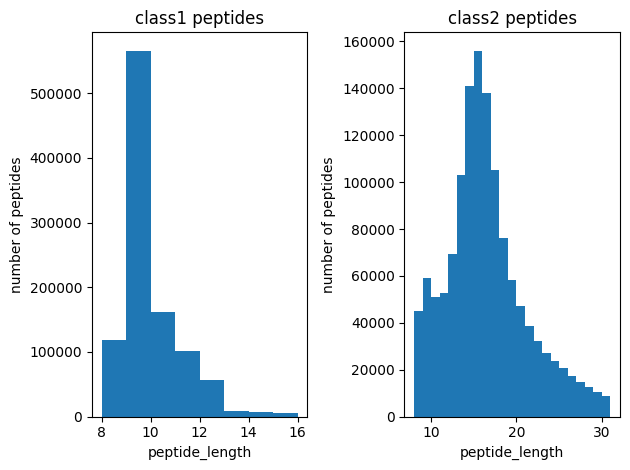

In [ ]:
# plot length distribution
class1_df = immunopeptidomes_df[immunopeptidomes_df['mhc_class']=='I']
class2_df = immunopeptidomes_df[immunopeptidomes_df['mhc_class']=='II']
class1_df.to_csv('CLL_NELDE_class1.csv')
class2_df.to_csv('CLL_NELDE_class2.csv')
length_distribution(class1_df[class1_df['accessions']!='unmapped'], class2_df[class2_df['accessions']!='unmapped'])

## Run epicore

In [ ]:
# classI
subprocess.run(['epicore', '--reference_proteome', '/mnt/volume/jana/thesis/data/CLL_warehouse_PXD024871/spHUMANwoi_130927_CLL_mut.fasta', '--out_dir', 'CLL_NELDE_classI_strict', 'generate-epicore-csv', '--min_epi_length', '8', '--min_overlap', '8', '--seq_column', 'sequence', '--protacc_column', 'accessions', '--delimiter', ';', '--evidence_file', 'CLL_NELDE_class1.csv', '--start_column', 'start', '--end_column', 'end', '--sample_column', 'sample', '--condition_column', 'condition', '--strict'])
subprocess.run(['epicore', '--reference_proteome', '/mnt/volume/jana/thesis/data/CLL_warehouse_PXD024871/spHUMANwoi_130927_CLL_mut.fasta', '--out_dir', 'CLL_NELDE_classI_included', 'generate-epicore-csv', '--min_epi_length', '8', '--min_overlap', '8', '--seq_column', 'sequence', '--protacc_column', 'accessions', '--delimiter', ';', '--evidence_file', 'CLL_NELDE_class1.csv', '--start_column', 'start', '--end_column', 'end', '--sample_column', 'sample', '--condition_column', 'condition', '--included'])

CompletedProcess(args=['epicore', '--reference_proteome', '/mnt/volume/jana/thesis/data/CLL_warehouse_PXD024871/spHUMANwoi_130927_CLL_mut.fasta', '--out_dir', 'CLL_NELDE_classI_included', 'generate-epicore-csv', '--min_epi_length', '8', '--min_overlap', '8', '--seq_column', 'sequence', '--protacc_column', 'accessions', '--delimiter', ';', '--evidence_file', 'CLL_NELDE_class1.csv', '--start_column', 'start', '--end_column', 'end', '--sample_column', 'sample', '--condition_column', 'condition', '--included'], returncode=0)

In [ ]:
# classII for strict, included and loose
subprocess.run(['epicore', '--reference_proteome', '/mnt/volume/jana/thesis/data/CLL_warehouse_PXD024871/spHUMANwoi_130927_CLL_mut.fasta', '--out_dir', 'CLL_NELDE_classII_strict_9', 'generate-epicore-csv', '--min_epi_length', '9', '--min_overlap', '9', '--seq_column', 'sequence', '--protacc_column', 'accessions', '--delimiter', ';', '--evidence_file', 'CLL_NELDE_class2.csv', '--start_column', 'start', '--end_column', 'end', '--sample_column', 'sample', '--condition_column', 'condition', '--strict'])
subprocess.run(['epicore', '--reference_proteome', '/mnt/volume/jana/thesis/data/CLL_warehouse_PXD024871/spHUMANwoi_130927_CLL_mut.fasta', '--out_dir', 'CLL_NELDE_classII_included_9', 'generate-epicore-csv', '--min_epi_length', '9', '--min_overlap', '9', '--seq_column', 'sequence', '--protacc_column', 'accessions', '--delimiter', ';', '--evidence_file', 'CLL_NELDE_class2.csv', '--start_column', 'start', '--end_column', 'end', '--sample_column', 'sample', '--condition_column', 'condition', '--included'])
subprocess.run(['epicore', '--reference_proteome', '/mnt/volume/jana/thesis/data/CLL_warehouse_PXD024871/spHUMANwoi_130927_CLL_mut.fasta', '--out_dir', 'CLL_NELDE_classII_loose_9', 'generate-epicore-csv', '--min_epi_length', '9', '--min_overlap', '9', '--seq_column', 'sequence', '--protacc_column', 'accessions', '--delimiter', ';', '--evidence_file', 'CLL_NELDE_class2.csv', '--start_column', 'start', '--end_column', 'end', '--sample_column', 'sample', '--condition_column', 'condition'])

CompletedProcess(args=['epicore', '--reference_proteome', '/mnt/volume/jana/thesis/data/CLL_warehouse_PXD024871/spHUMANwoi_130927_CLL_mut.fasta', '--out_dir', 'CLL_NELDE_classII_loose_9', 'generate-epicore-csv', '--min_epi_length', '9', '--min_overlap', '9', '--seq_column', 'sequence', '--protacc_column', 'accessions', '--delimiter', ';', '--evidence_file', 'CLL_NELDE_class2.csv', '--start_column', 'start', '--end_column', 'end', '--sample_column', 'sample', '--condition_column', 'condition'], returncode=0)

## General

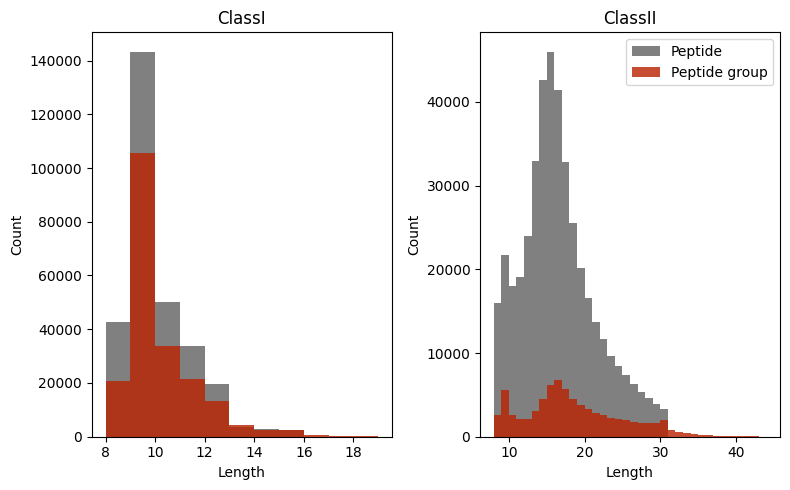

In [ ]:
# plot length distribution of peptide groups and peptides for classI
fig, axis = plt.subplots(1,2, figsize=(8,5))
peptidegroups_cI_df = pd.read_csv('CLL_NELDE_classI_included/epitopes.csv', index_col=[0])
peptidegroups_cI_df = peptidegroups_cI_df[peptidegroups_cI_df['whole_epitopes'].str.len()<50]
peptides_cI_lens = pd.read_csv('CLL_NELDE_class1.csv', usecols=['sequence'])['sequence'].drop_duplicates().str.len()
axis[0].set_title('ClassI')
axis[0].hist(peptides_cI_lens,bins=[i for i in range(8,20)], color='grey')
axis[0].hist(peptidegroups_cI_df['whole_epitopes'].drop_duplicates().str.len(),bins=[i for i in range(8,20)], color="#bb2402cf")
axis[0].set_xlabel('Length')
axis[0].set_ylabel('Count')

# plot length distribution of peptide groups and peptides for classII
peptidegroups_cII_df = pd.read_csv('CLL_NELDE_classII_included_9/epitopes.csv', index_col=[0])
peptidegroups_cII_df = peptidegroups_cII_df[peptidegroups_cII_df['whole_epitopes'].str.len()<50]
peptides_cII_lens = pd.read_csv('CLL_NELDE_class2.csv', usecols=['sequence'])['sequence'].drop_duplicates().str.len()
axis[1].set_title('ClassII')
axis[1].hist(peptides_cII_lens,bins=[i for i in range(8,45)], color='grey', label='Peptide')
axis[1].hist(peptidegroups_cII_df['whole_epitopes'].drop_duplicates().str.len(),bins=[i for i in range(8,45)], color="#bb2402cf", label='Peptide group')
axis[1].set_xlabel('Length')
axis[1].set_ylabel('Count')
plt.legend()
plt.tight_layout()
plt.savefig('figures/CLL_NELDE_consensus_peptide_length_dist.svg')
plt.show()

In [ ]:
# identify complexity reduction
peptidesI = pd.read_csv('CLL_NELDE_class1.csv', usecols=['sequence'])['sequence'].drop_duplicates()
peptidesII = pd.read_csv('CLL_NELDE_class2.csv', usecols=['sequence'])['sequence'].drop_duplicates()
print(f"ClassI: {len(peptidesI)} peptides, {len(peptidegroups_cI_df.drop_duplicates(['whole_epitopes', 'consensus_epitopes']))} peptide groups.")
print(f"ClassII: {len(peptidesII)} peptides, {len(peptidegroups_cII_df.drop_duplicates(['whole_epitopes', 'consensus_epitopes']))} peptide groups.")

ClassI: 299033 peptides, 205360 peptide groups.
ClassII: 431192 peptides, 76420 peptide groups.


## Determine candidates

### Class2

In [2]:
# calculate consensus and peptide frequencies for teh included mode
consfreq_cII_included = consensus_frequency('CLL_NELDE_classII_included_9/epitopes.csv')
pepfreq_cII = peptide_frequency('CLL_NELDE_class2.csv')

# combine frequencies
consfreq_cII_included['grouped_peptides_sequence'] = consfreq_cII_included['grouped_peptides_sequence'].apply(lambda sequences: set(itertools.chain(*sequences)))
consfreq_cII_included = consfreq_cII_included.explode(['grouped_peptides_sequence'])
freq_cII_included = pd.merge(consfreq_cII_included[['whole_epitopes', 'consensus_epitopes','grouped_peptides_sequence', 'benign_frequency', 'malignant_frequency']], pepfreq_cII[['sequence', 'benign_frequency', 'malignant_frequency']], left_on='grouped_peptides_sequence', right_on='sequence', suffixes=('_epicore','_single'))
sanity_check(freq_cII_included)

In [18]:
# calculate consensus frequencies for the strict mode
consfreq_cII_strict = consensus_frequency('CLL_NELDE_classII_strict_9/epitopes.csv')

# combine frequencies
consfreq_cII_strict['grouped_peptides_sequence'] = consfreq_cII_strict['grouped_peptides_sequence'].apply(lambda sequences: set(itertools.chain(*sequences)))
consfreq_cII_strict = consfreq_cII_strict.explode(['grouped_peptides_sequence'])
freq_cII_strict = pd.merge(consfreq_cII_strict[['whole_epitopes', 'consensus_epitopes','grouped_peptides_sequence', 'benign_frequency', 'malignant_frequency']], pepfreq_cII[['sequence', 'benign_frequency', 'malignant_frequency']], left_on='grouped_peptides_sequence', right_on='sequence', suffixes=('_epicore','_single'))
sanity_check(freq_cII_strict)

In [ ]:
# calculate consensus frequencies for the loose mode
consfreq_cII_loose = consensus_frequency('CLL_NELDE_classII_loose_9/epitopes.csv')

# combine frequencies
consfreq_cII_loose['grouped_peptides_sequence'] = consfreq_cII_loose['grouped_peptides_sequence'].apply(lambda sequences: set(itertools.chain(*sequences)))
consfreq_cII_loose = consfreq_cII_loose.explode(['grouped_peptides_sequence'])
freq_cII_loose = pd.merge(consfreq_cII_loose[['whole_epitopes', 'consensus_epitopes','grouped_peptides_sequence', 'benign_frequency', 'malignant_frequency']], pepfreq_cII[['sequence', 'benign_frequency', 'malignant_frequency']], left_on='grouped_peptides_sequence', right_on='sequence', suffixes=('_epicore','_single'))
sanity_check(freq_cII_strict)

Create waterfall plot on peptide and peptide group level. 

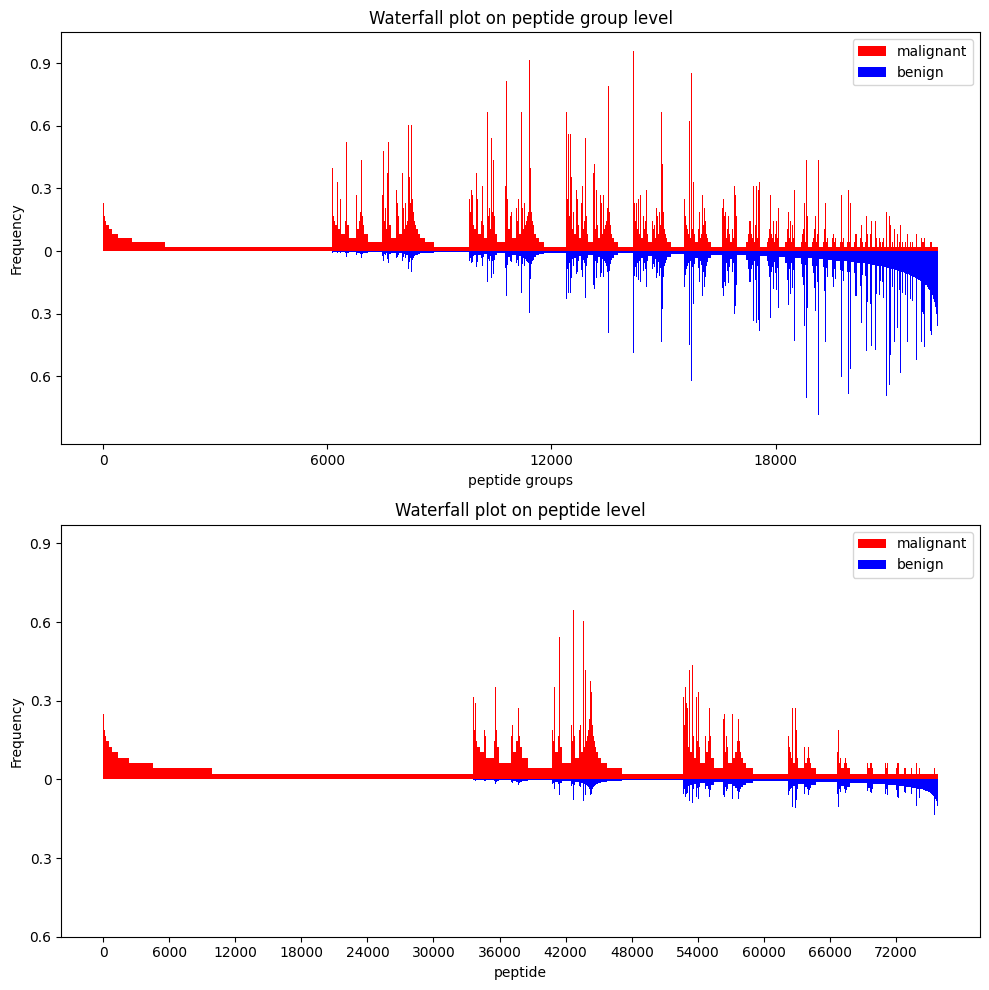

In [ ]:
fig, axis = plt.subplots(2,1, figsize=(10,10))
axis[0].set_title('Waterfall plot on peptide group level')
plot_waterfall(consfreq_cII_included, 'whole_epitopes', 'peptide groups', axis[0])
axis[1].set_title('Waterfall plot on peptide level')
plot_waterfall(pepfreq_cII, 'sequence', 'peptide', axis[1])
plt.tight_layout()
plt.savefig('figures/waterfall_entire.svg')
plt.show()


In [ ]:
# identify the mean frequency increase in malignant and benign 
freq_cII_duplicated = freq_cII_included[freq_cII_included.duplicated('whole_epitopes', keep=False)]
freqgain_df = freq_cII_duplicated.groupby('whole_epitopes').agg({'benign_frequency_epicore':'first', 'benign_frequency_single':'max', 'malignant_frequency_epicore':'first', 'malignant_frequency_single':'max'})
freqgain_df['benign_increase'] = freqgain_df.apply(lambda row: row['benign_frequency_epicore']-row['benign_frequency_single'], axis=1)
freqgain_df['malignant_increase'] = freqgain_df.apply(lambda row: row['malignant_frequency_epicore']-row['malignant_frequency_single'], axis=1)
print(f"The mean benign frequency increase per peptide group is {freqgain_df['benign_increase'].mean()}")
print(f"The mean malignant frequency increase per peptide group is {freqgain_df['malignant_increase'].mean()}")

The mean benign frequency increase per peptide group is 0.029552776795074245
The mean malignant frequency increase per peptide group is 0.008870081568826339


Zoom into candidate region on peptide group level. And compare the candidate region on peptide and peptide group level. 

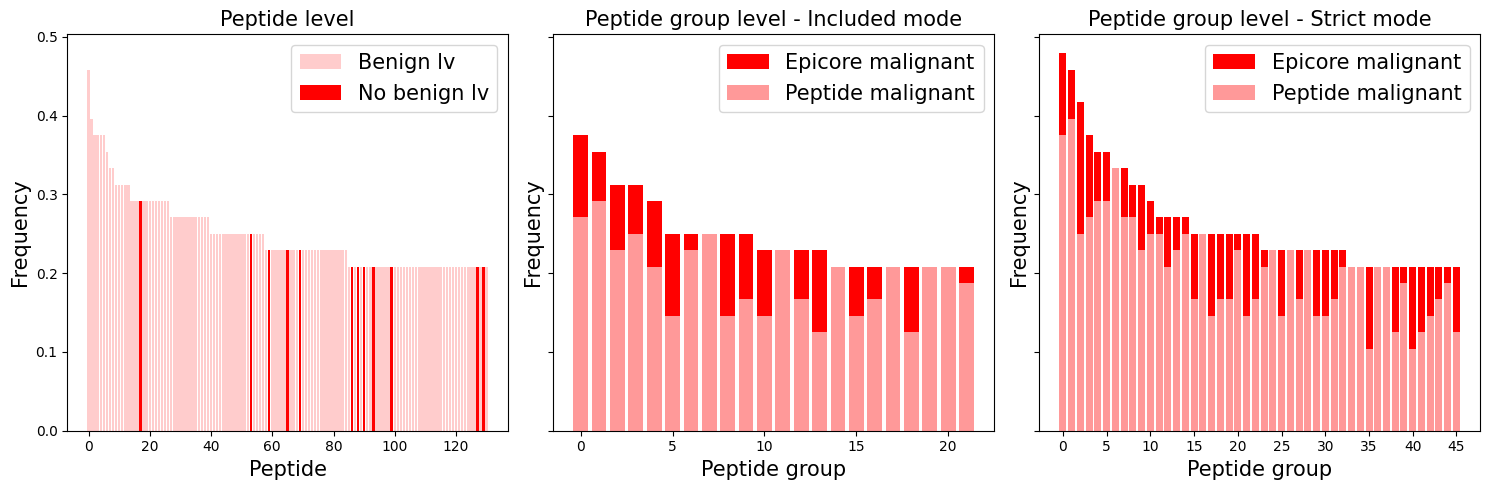

In [ ]:
# benign frequency 0% and malignant frequency >= 20%
fig, axis = plt.subplots(1,3, figsize=(15,5), sharey=True)
axis[1].set_title('Peptide group level - Included mode', fontsize=15)
axis[0].set_title('Peptide level', fontsize=15)
axis[2].set_title('Peptide group level - Strict mode', fontsize=15)
candidate_region_epicore(freq_cII_included , axis[1], 0.2, 0)
candidate_region_peptide(freq_cII_included , axis[0], 0.2, 0, 0)
candidate_region_epicore(freq_cII_strict, axis[2], 0.2, 0)
axis[0].set_ylabel('Frequency', fontsize=15)
plt.tight_layout()
plt.savefig('figures/candidate_region_CLL.svg')

In [ ]:
freq_cII_included[(freq_cII_included['benign_frequency_single']==0)&(freq_cII_included['malignant_frequency_single']>=0.2)&(freq_cII_included['benign_frequency_epicore']==0)].drop_duplicates('sequence')

,whole_epitopes,consensus_epitopes,grouped_peptides_sequence,benign_frequency_epicore,malignant_frequency_epicore,sequence,benign_frequency_single,malignant_frequency_single
43593,AQTTKHKWEAAHVAEQLRAY,[KHKWEAAHVAEQ],TKHKWEAAHVAEQLR,0.0,0.250000,TKHKWEAAHVAEQLR,0.0,0.229167
63935,AYNRRTFETARHNLIINIM,[NRRTFETARHNL],NRRTFETARHNLIIN,0.0,0.208333,NRRTFETARHNLIIN,0.0,0.208333
77944,DGETRKVKAHSQTHRVDLGTLR,[KVKAHSQTHR],ETRKVKAHSQTHRVD,0.0,0.250000,ETRKVKAHSQTHRVD,0.0,0.208333
77963,DGETRKVKAHSQTHRVDLGTLR,[KVKAHSQTHR],DGETRKVKAHSQTHRVD,0.0,0.250000,DGETRKVKAHSQTHRVD,0.0,0.250000
77969,DGETRKVKAHSQTHRVDLGTLR,[KVKAHSQTHR],DGETRKVKAHSQTHRVDLG,0.0,0.250000,DGETRKVKAHSQTHRVDLG,0.0,0.208333
92046,DNRNLKYLPFVPSRMKYVY,[NLKYLPFVPSR],DNRNLKYLPFVPSRMK,0.0,0.312500,DNRNLKYLPFVPSRMK,0.0,0.208333
92048,DNRNLKYLPFVPSRMKYVY,[NLKYLPFVPSR],RNLKYLPFVPSRMK,0.0,0.312500,RNLKYLPFVPSRMK,0.0,0.229167
148663,FDIILSTSPHCCWWI,[FDIILSTSPHCCWWI],FDIILSTSPHCCWWI,0.0,0.229167,FDIILSTSPHCCWWI,0.0,0.229167
303390,KPPLPQPGPEKGALDLGLLSQEGEAAT,[KPPLPQPGPEKGALDLGLLSQEGEAAT],KPPLPQPGPEKGALDLGLLSQEGEAAT,0.0,0.208333,KPPLPQPGPEKGALDLGLLSQEGEAAT,0.0,0.208333
313083,KVVNEMCPNITRIYNIGK,[KVVNEMCPNITRIYNIGK],KVVNEMCPNITRIYNIGK,0.0,0.208333,KVVNEMCPNITRIYNIGK,0.0,0.208333


In [ ]:
freq_cII_included[(freq_cII_included['benign_frequency_single']==0)&(freq_cII_included['malignant_frequency_single']>=0.2)].drop_duplicates('sequence')

,whole_epitopes,consensus_epitopes,grouped_peptides_sequence,benign_frequency_epicore,malignant_frequency_epicore,sequence,benign_frequency_single,malignant_frequency_single
1164,AADTAAQITQRKWEAARVAEQLRTYLE,[ITQRKWEAA],ITQRKWEAARVAEQ,0.062937,0.458333,ITQRKWEAARVAEQ,0.0,0.250000
1166,AADTAAQITQRKWEAARVAEQLRTYLE,[ITQRKWEAA],QRKWEAARVAEQLR,0.062937,0.458333,QRKWEAARVAEQLR,0.0,0.208333
1221,AADTAAQITQRKWEAARVAEQLRTYLE,[ITQRKWEAA],ITQRKWEAARVA,0.062937,0.458333,ITQRKWEAARVA,0.0,0.208333
7509,ADEVQVFAPANALPARSEAAAVQPVIGISQRV,[VFAPANALPARSE],LPARSEAAAVQPVIG,0.048951,0.354167,LPARSEAAAVQPVIG,0.0,0.312500
19007,AGSHSMRYFYTAMSRPGRGEPRFI,[YFYTAMSRP],GSHSMRYFYTAMSRPGRGEPR,0.038462,0.541667,GSHSMRYFYTAMSRPGRGEPR,0.0,0.291667
...,...,...,...,...,...,...,...,...
580532,VPSAPRRQDSEDHSSDMFNYEEYCTANAVT,[DMFNYEEYCTA],SDMFNYEEYCTANAV,0.059441,0.458333,SDMFNYEEYCTANAV,0.0,0.291667
583813,VRFLDRYFYNQEEYVRFDSDVG,[FYNQEEYVR],LDRYFYNQEEYVR,0.118881,0.375000,LDRYFYNQEEYVR,0.0,0.291667
583818,VRFLDRYFYNQEEYVRFDSDVG,[FYNQEEYVR],LDRYFYNQEEYVRFD,0.118881,0.375000,LDRYFYNQEEYVRFD,0.0,0.270833
583835,VRFLDRYFYNQEEYVRFDSDVG,[FYNQEEYVR],LDRYFYNQEEYVRFDS,0.118881,0.375000,LDRYFYNQEEYVRFDS,0.0,0.270833


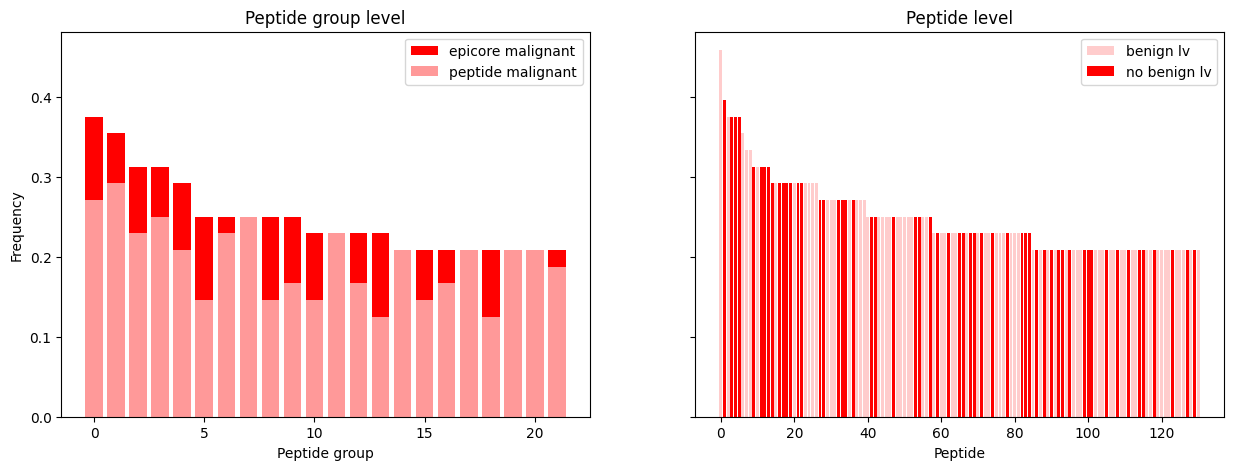

In [ ]:
# allow benign frequency of 5% on peptide level
fig, axis = plt.subplots(1,2, figsize=(15,5), sharey=True)
axis[0].set_title('Peptide group level')
axis[1].set_title('Peptide level')
candidate_region_epicore(freq_cII_included , axis[0], 0.2, 0)
candidate_region_peptide(freq_cII_included , axis[1], 0.2, 0, 0.05)

In [ ]:
print(f"{len(freq_cII_included[(freq_cII_included['benign_frequency_epicore']<=0.05)&(freq_cII_included['malignant_frequency_epicore']>=0.2)].drop_duplicates('whole_epitopes'))} peptide groups fulfil the condition of below 5% benign frequency and over 20% malignant frequency.")
print(f"{len(freq_cII_included[(freq_cII_included['benign_frequency_epicore']<=0.05)&(freq_cII_included['malignant_frequency_epicore']>=0.2)&(freq_cII_included['benign_frequency_single']==0)&(freq_cII_included['malignant_frequency_single']>=0.2)].drop_duplicates('whole_epitopes'))} peptides fulfill the same conditions.")

485 peptide groups fulfil the condition of below 5% benign frequency and over 20% malignant frequency.
55 peptides fulfill the same conditions.


Identify number of candidates with a higher prioritization due to epicore.

In [ ]:
# get candidate region
df = freq_cII_included.groupby(['whole_epitopes']).agg({'malignant_frequency_epicore':'first', 'benign_frequency_epicore':'first', 'malignant_frequency_single':'max', 'benign_frequency_single':'max'})
df['ratio'] = (df['benign_frequency_epicore'] + 0.000001) / (df['malignant_frequency_epicore'] + 0.000001)
df = df[(df['benign_frequency_epicore']<=0)&(df['malignant_frequency_epicore']>=0.2)]
df = df.sort_values(['malignant_frequency_single', 'benign_frequency_single'], ascending=[False, True])

# identify rank on peptide level
df['prev_malignant'] = df['malignant_frequency_single'].shift(-1)
df['rank'] = df.apply(lambda row: 1 if row['prev_malignant']!=row['malignant_frequency_single'] else 0, axis=1)
df['rank'] = df['rank'].cumsum()
df['rank'] = df['rank'].shift(1)
df.at[df.index[0],'rank'] = 0
df = df.sort_values('ratio')
df = df.sort_values(['malignant_frequency_epicore', 'benign_frequency_epicore'], ascending=[False, True])

# identify rank on peptide group level
df['prev_malignant'] = df['malignant_frequency_epicore'].shift(-1)
df['rank_epicore'] = df.apply(lambda row: 1 if row['prev_malignant']!=row['malignant_frequency_epicore'] else 0, axis=1)
df['rank_epicore'] = df['rank_epicore'].cumsum()
df['rank_epicore'] = df['rank_epicore'].shift(1)

# identify how many candidates have higher rank due to epicore
df.at[df.index[0],'rank_epicore'] = 0
print(f"{len(df[df['rank']>df['rank_epicore']])} peptide groups have higher prioritization due to epicore.")

11 peptide groups have higher prioritization due to epicore.


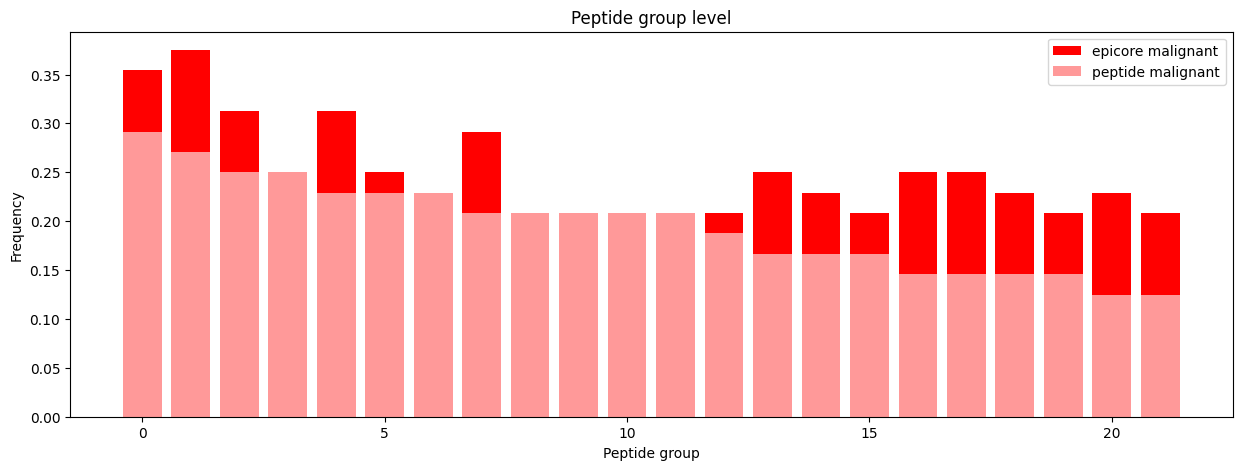

In [ ]:
# plot the peptide groups in the order of their rank on peptide level
fig, axis = plt.subplots(1,1, figsize=(15,5), sharey=True)
axis.set_title('Peptide group level')
candidate_region_epicore(freq_cII_included , axis, 0.2, 0, True)

Show the candidate region for different filter criteria.

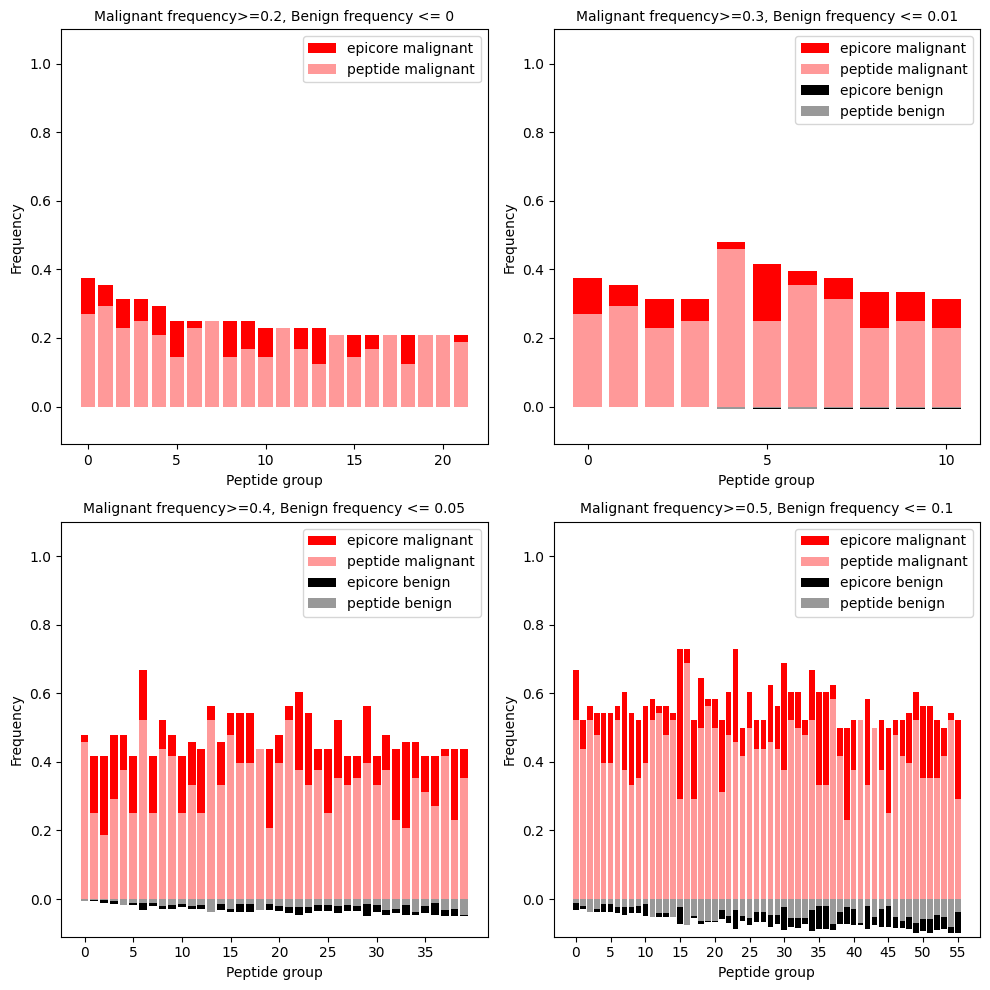

In [ ]:
fig, axis = plt.subplots(2,2, figsize=(10,10))
axis[0,0].set_title('Malignant frequency>=0.2, Benign frequency <= 0', fontdict={'fontsize':10})
candidate_region_epicore(freq_cII_included, axis[0,0], 0.2, 0)
axis[0,0].set_ylim([-0.11, 1.1])
axis[0,1].set_title('Malignant frequency>=0.3, Benign frequency <= 0.01', fontdict={'fontsize':10})
candidate_region_epicore(freq_cII_included, axis[0,1], 0.3, 0.01)
axis[0,1].set_ylim([-0.11, 1.1])
axis[1,0].set_title('Malignant frequency>=0.4, Benign frequency <= 0.05', fontdict={'fontsize':10})
candidate_region_epicore(freq_cII_included, axis[1,0], 0.4, 0.05)
axis[1,0].set_ylim([-0.11, 1.1])
axis[1,1].set_title('Malignant frequency>=0.5, Benign frequency <= 0.1', fontdict={'fontsize':10})
candidate_region_epicore(freq_cII_included, axis[1,1], 0.5, 0.1)
axis[1,1].set_ylim([-0.11, 1.1])
plt.legend()
plt.tight_layout()
plt.savefig('figures/candidate_regions_CLL.svg')
plt.show()

In [ ]:
# identify how many peptides and peptide group match the different filter criteria
conditions = [[0.2,0],[0.3,0.01],[0.4,0.05],[0.5,0.1]]
condition_df = pd.DataFrame({'condition':[], 'peptides':[], 'peptide_groups':[]})
for condition in conditions:
    peptides = len(freq_cII_included[(freq_cII_included['malignant_frequency_single']>=condition[0])&(freq_cII_included['benign_frequency_single']<=condition[1])&(freq_cII_included['benign_frequency_epicore']<=condition[1])].drop_duplicates('grouped_peptides_sequence'))
    peptide_groups = len(freq_cII_included[(freq_cII_included['malignant_frequency_epicore']>=condition[0])&(freq_cII_included['benign_frequency_epicore']<=condition[1])].drop_duplicates('whole_epitopes'))
    condition_df.loc[len(condition_df)] = [f'condition', peptides, peptide_groups]
condition_df

,condition,peptides,peptide_groups
0,condition,15,22
1,condition,3,11
2,condition,11,40
3,condition,18,56


Determine peptide flow from peptides on sequence level to consensus level. 

In [15]:
frequency_agg = freq_cII_included.groupby(['grouped_peptides_sequence', 'whole_epitopes']).agg({'benign_frequency_epicore':'max', 'malignant_frequency_epicore':'max','benign_frequency_single':'max', 'malignant_frequency_single':'max'}).reset_index()
flows = sequence_flow(frequency_agg, 'benign_frequency_single', 'benign_frequency_epicore', 'malignant_frequency_single' , 'malignant_frequency_epicore')
plot_flow_all(flows)

In [16]:
print(f"{len(frequency_agg[(frequency_agg['benign_frequency_epicore']==0)&(frequency_agg['malignant_frequency_epicore']>=0.2)].drop_duplicates('whole_epitopes'))} peptide groups are candidates.")
print(f"{len(frequency_agg[(frequency_agg['benign_frequency_epicore']==0)&(frequency_agg['malignant_frequency_epicore']<0.2)].drop_duplicates('whole_epitopes'))} peptide groups are malignant.")
print(f"{len(frequency_agg[(frequency_agg['benign_frequency_epicore']>0)&(frequency_agg['malignant_frequency_epicore']>0)].drop_duplicates('whole_epitopes'))} Peptide groups are covered by benign and malignant peptides.")

22 peptide groups are candidates.
6097 peptide groups are malignant.
16230 Peptide groups are covered by benign and malignant peptides.


Visualize the top five candidates identified with epicore.

In [ ]:
# identify the candidates
candidate_df_included = freq_cII_included.groupby(['whole_epitopes']).agg({'malignant_frequency_epicore':'first', 'benign_frequency_epicore':'first', 'malignant_frequency_single':'max', 'benign_frequency_single':'max'})
candidate_df_included = candidate_df_included.sort_values(['benign_frequency_epicore', 'malignant_frequency_epicore'], ascending=[True, False])
epicore_classII_candidates = candidate_df_included.reset_index().head(5)['whole_epitopes'].to_list()

In [ ]:
class2_df = pd.read_csv('CLL_NELDE_class2.csv', usecols=['sample', 'condition'])
c2_benign_n = len(class2_df[class2_df['condition'].str.contains('benign')]['sample'].unique())
c2_malignant = class2_df[class2_df['condition'].str.contains('malignant')]['sample'].unique()

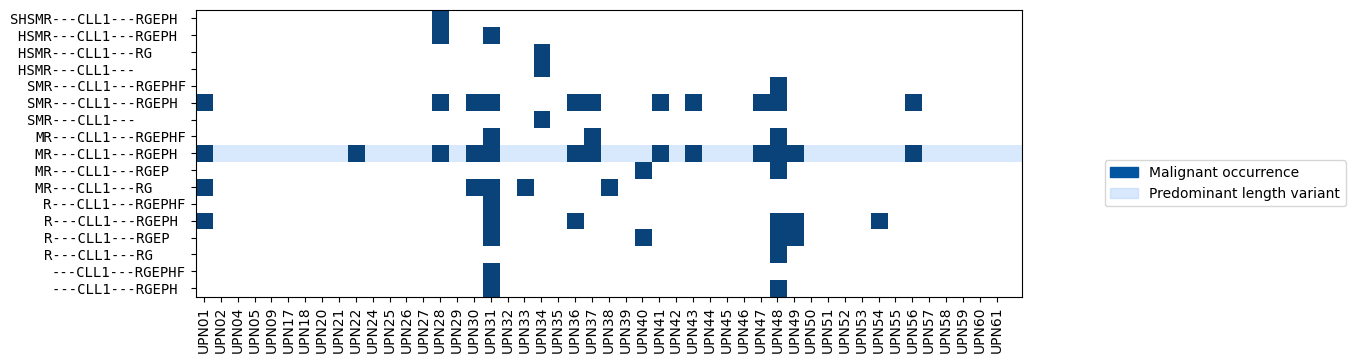

In [ ]:
# identify the candidates
candidate_df_included = freq_cII_included.groupby(['whole_epitopes']).agg({'malignant_frequency_epicore':'first', 'benign_frequency_epicore':'first', 'malignant_frequency_single':'max', 'benign_frequency_single':'max'})
candidate_df_included = candidate_df_included.sort_values(['benign_frequency_epicore', 'malignant_frequency_epicore'], ascending=[True, False])
epicore_c2_candidates = candidate_df_included.reset_index().head(5)['whole_epitopes'].to_list()


fig, ax = plt.subplots(1,1,figsize=(15,7), sharex=True)
im, legend_elements = candidate_heatmap('CLL_NELDE_classII_included_9/epitopes.csv', epicore_c2_candidates[0], ax, 3, 'CLL1',(1.6,0.5), allotype_samples=c2_malignant, n_benign=c2_benign_n, vmax=0.05)
ax.legend(handles=legend_elements, bbox_to_anchor=(1.4,0.5))
plt.tight_layout()
plt.savefig('figures/top_candidate.svg')
plt.show()

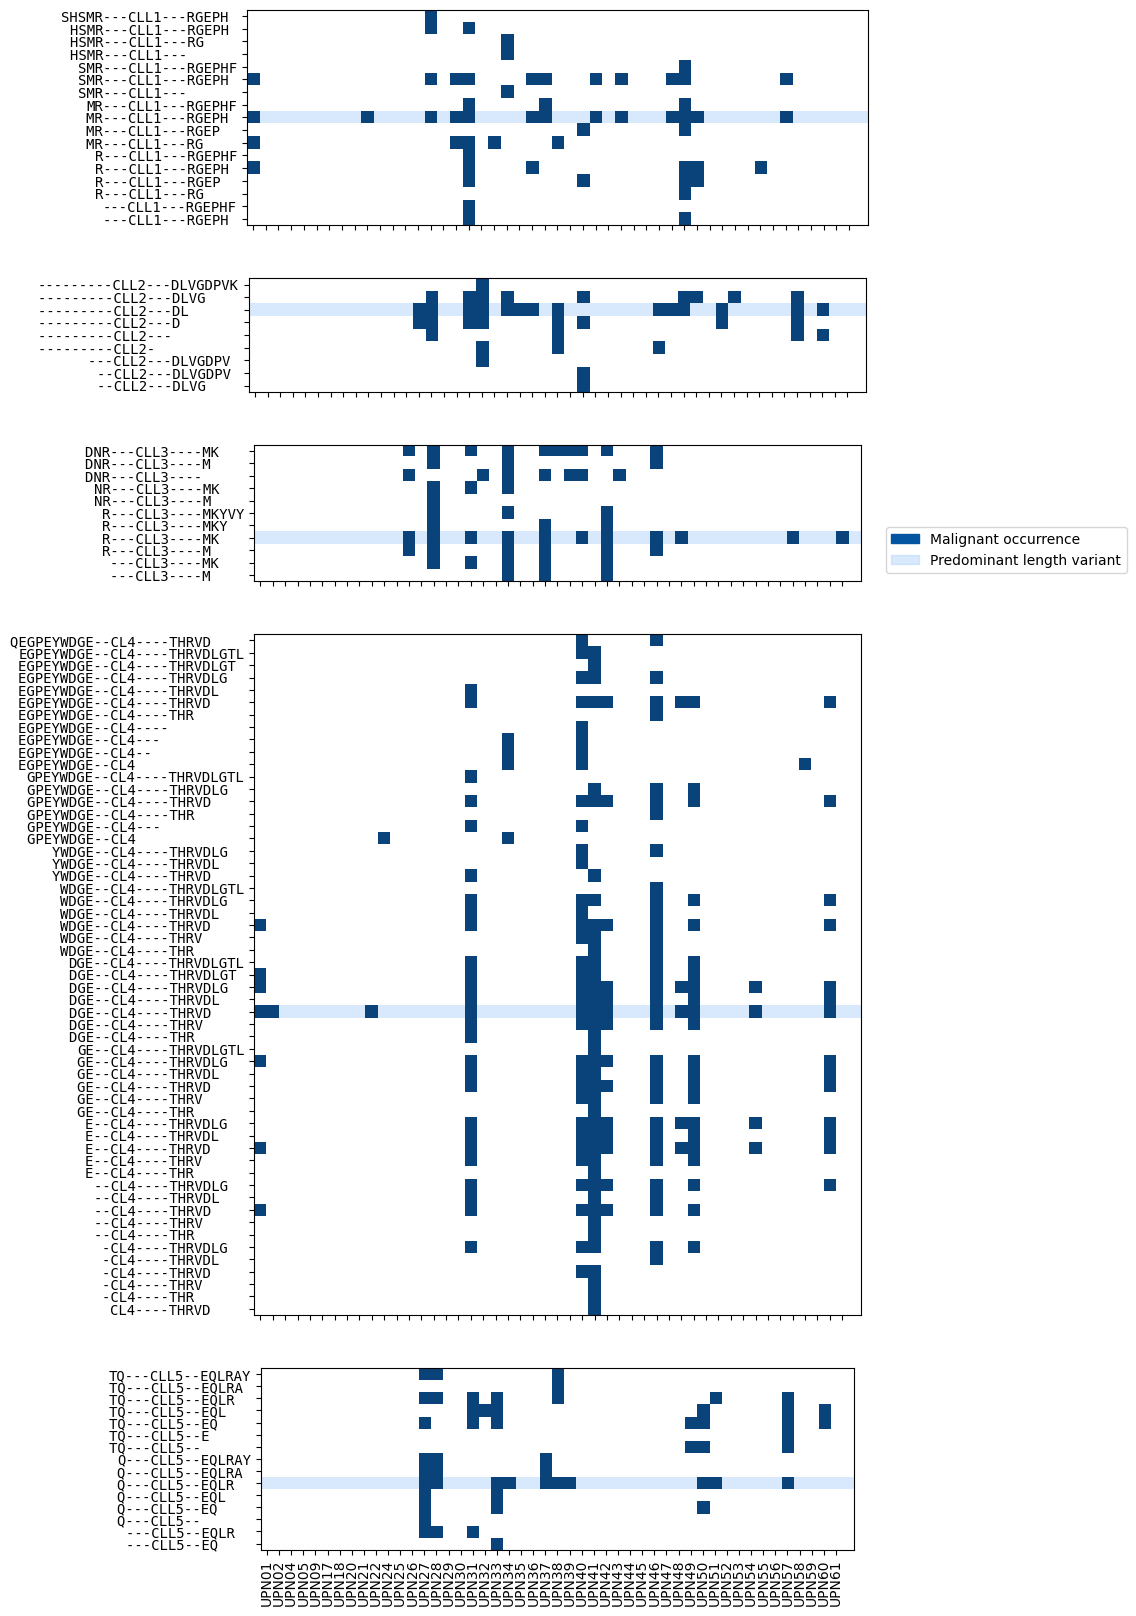

In [ ]:
# identify the candidates
candidate_df_included = freq_cII_included.groupby(['whole_epitopes']).agg({'malignant_frequency_epicore':'first', 'benign_frequency_epicore':'first', 'malignant_frequency_single':'max', 'benign_frequency_single':'max'})
candidate_df_included = candidate_df_included.sort_values(['benign_frequency_epicore', 'malignant_frequency_epicore'], ascending=[True, False])
epicore_c2_candidates = candidate_df_included.reset_index().head(5)['whole_epitopes'].to_list()


fig, ax = plt.subplots(5,1,figsize=(40,20), sharex=True, height_ratios=[19/111, 10/111, 12/111,60/111,16/111])
candidate_heatmap('CLL_NELDE_classII_included_9/epitopes.csv', epicore_c2_candidates[0], ax[0], 3, 'CLL1',(1.6,0.5), allotype_samples=c2_malignant, n_benign=c2_benign_n, vmax=0.05)
candidate_heatmap('CLL_NELDE_classII_included_9/epitopes.csv', epicore_c2_candidates[1], ax[1], [9,9,9,9,9,9,3,2,2], 'CLL2',(1.6,0.5), allotype_samples=c2_malignant, n_benign=c2_benign_n, vmax=0.05)
im, legend_elements = candidate_heatmap('CLL_NELDE_classII_included_9/epitopes.csv', epicore_c2_candidates[2], ax[2], 3, 'CLL3',(1.6,0.5), allotype_samples=c2_malignant, n_benign=c2_benign_n, vmax=0.05)
candidate_heatmap('CLL_NELDE_classII_included_9/epitopes.csv', epicore_c2_candidates[3], ax[3], 49*[2]+5*[1]+[0], 'CL4',(1.6,0.5), allotype_samples=c2_malignant, n_benign=c2_benign_n, vmax=0.05)
candidate_heatmap('CLL_NELDE_classII_included_9/epitopes.csv', epicore_c2_candidates[4], ax[4], 3, 'CLL5',(1.6,0.5), allotype_samples=c2_malignant, n_benign=c2_benign_n, vmax=0.05)
ax[2].legend(handles=legend_elements, bbox_to_anchor=(1.45,0.45))

#plt.tight_layout()
plt.savefig('figures/CLL_epicore_candidates_class2.svg', bbox_inches='tight')

Compare the strict mode to the included mode.

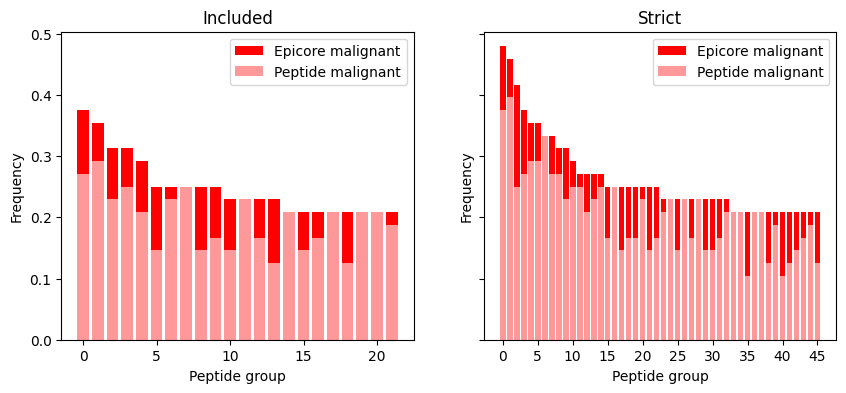

In [ ]:
# visualize candidate region in strict and loose mode
fig, axis = plt.subplots(1,2, figsize=(10,4), sharey=True)
axis[0].set_title('Included')
axis[1].set_title('Strict')
candidate_region_epicore(freq_cII_included, axis[0], 0.2, 0)
candidate_region_epicore(freq_cII_strict, axis[1], 0.2, 0)
plt.savefig('figures/CLL_included_strict.svg')

In [ ]:
included_candidates = freq_cII_included[(freq_cII_included['malignant_frequency_epicore']>=0.2)&(freq_cII_included['benign_frequency_epicore']==0)]['whole_epitopes'].unique()
strict_candidates = freq_cII_strict[(freq_cII_strict['malignant_frequency_epicore']>=0.2)&(freq_cII_strict['benign_frequency_epicore']==0)]['whole_epitopes'].unique()

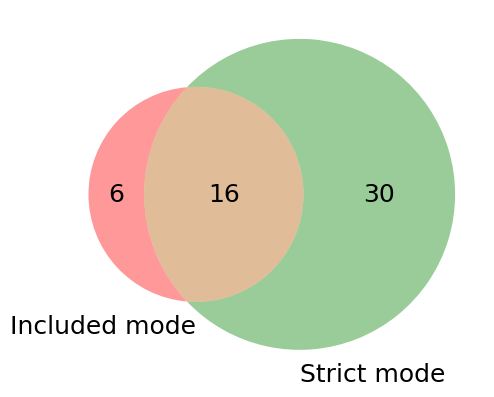

In [ ]:

plot = venn2([set(included_candidates), set(strict_candidates)], ('Included mode', 'Strict mode'))
for label in plot.set_labels:
    label.set_fontsize(18)
for label in plot.subset_labels:
    label.set_fontsize(18)

plt.savefig('figures/mode_venn.svg')

In [ ]:
# get the candidate groups from the included and strict mode
strict_candidates = freq_cII_strict[(freq_cII_strict['benign_frequency_epicore']==0)&(freq_cII_strict['malignant_frequency_epicore']>=0.2)].drop_duplicates('whole_epitopes').sort_values('malignant_frequency_epicore', ascending=False)
included_candidates = freq_cII_included[(freq_cII_included['benign_frequency_epicore']==0)&(freq_cII_included['malignant_frequency_epicore']>=0.2)].drop_duplicates('whole_epitopes').sort_values('malignant_frequency_epicore', ascending=False)

print(f"The frequency of the top candidate in the strict mode is {strict_candidates.iloc[0]['malignant_frequency_epicore']}")
print(f"The frequency of the top candidate in the included mode is {included_candidates.iloc[0]['malignant_frequency_epicore']}")
print(f"The mean of the top ten candidates in the strict mode is {np.mean(strict_candidates.head(10)['malignant_frequency_epicore'])}")
print(f"The mean of the top ten candidates in the included mode is {np.mean(included_candidates.head(10)['malignant_frequency_epicore'])}")

The frequency of the top candidate in the strict mode is 0.4791666666666667
The frequency of the top candidate in the included mode is 0.375
The mean of the top ten candidates in the strict mode is 0.3729166666666667
The mean of the top ten candidates in the included mode is 0.28958333333333336


In [ ]:
# identify the corresponding peptide groups of the included mode epicore run for all candidates of the strict mode epicore run
freq_cII_included_agg = freq_cII_included.groupby(['whole_epitopes']).agg({'malignant_frequency_epicore':'first', 'benign_frequency_epicore':'first', 'malignant_frequency_single':'max', 'benign_frequency_single':'max'}).reset_index()
freq_cII_strict_agg = freq_cII_strict.groupby(['whole_epitopes']).agg({'malignant_frequency_epicore':'first', 'benign_frequency_epicore':'first', 'malignant_frequency_single':'max', 'benign_frequency_single':'max'}).reset_index()
freq_cII_strict_agg_candidates = freq_cII_strict_agg[(freq_cII_strict_agg['malignant_frequency_epicore']>=0.2)&(freq_cII_strict_agg['benign_frequency_epicore']==0)].copy()
freq_cII_strict_agg_candidates['included_epitopes'] = freq_cII_strict_agg_candidates['whole_epitopes'].apply(lambda cell: freq_cII_included_agg[freq_cII_included_agg['whole_epitopes']==cell]['whole_epitopes'].unique())
freq_cII_strict_agg_candidates['included_epitopes'] = freq_cII_strict_agg_candidates.apply(lambda cell: freq_cII_included_agg[freq_cII_included_agg['whole_epitopes'].str.contains(cell['whole_epitopes'])]['whole_epitopes'].unique() if len(cell['included_epitopes'])==0 else cell['included_epitopes'], axis=1)
freq_cII_strict_agg_candidates['included_epitopes'] = freq_cII_strict_agg_candidates.apply(lambda cell: freq_cII_included_agg[freq_cII_included_agg['whole_epitopes'].str.contains(cell['whole_epitopes'][1:-1])]['whole_epitopes'].unique() if len(cell['included_epitopes'])==0 else cell['included_epitopes'], axis=1)

One peptide group has no directly corresponding peptide group in the included mode and is therefore omitted.

In [ ]:
freq_cII_strict_agg_candidates[freq_cII_strict_agg_candidates['included_epitopes'].str.len()==0]

,whole_epitopes,malignant_frequency_epicore,benign_frequency_epicore,malignant_frequency_single,benign_frequency_single,included_epitopes
31723,GRGEPRFITVGYVDDTLFVRFDSDAASPREEPR,0.208333,0.0,0.104167,0.0,[]


In [ ]:
# merge each strict candidate group with its corresponding included group
freq_cII_strict_agg_candidates['included_epitopes'] = freq_cII_strict_agg_candidates['included_epitopes'].apply(lambda cell: sorted(cell, key=lambda x: len(x))[-1] if len(cell)!=0 else cell)
freq_cII_strict_agg_candidates  = freq_cII_strict_agg_candidates.explode('included_epitopes')
candidate_freq_merged = pd.merge(freq_cII_strict_agg_candidates, freq_cII_included_agg, left_on='included_epitopes', right_on='whole_epitopes')
included_groups = candidate_freq_merged[candidate_freq_merged['benign_frequency_epicore_y']>0]['whole_epitopes_y'].unique()

In [ ]:
def get_samples(row):
    '''Check if all samples present in a strict peptide group can be covered with a subsequence of an included group.

    Args: 
        row: A row of a pandas Dataframe containing the strict and included version of a peptide group.

    Returns:
        Boolean indication if a subsequence covering all malignant and no benign samples of a strict peptide group can be found in the included peptide group. 
    '''
    samples = row['grouped_peptides_sample']
    starts = row['grouped_peptides_start']
    ends = row['grouped_peptides_end']
    df = pd.DataFrame({'samples':samples, 'starts':starts, 'ends':ends})

    # check coverage for all possible subsequences
    for start, end in row['combinations']:
        dfs = df[(df['starts']>=start)&(df['ends']<=end)]
        samples_covered = dfs['samples'].unique()
        benign_samples = [sample for sample in samples_covered if 'UPN' not in sample]

        # stop search when a subsequence that fulfills the coverage is found
        if (set(samples_covered) == row['all_UPN']) & (len(benign_samples)==0):
            return True
        
    return False

In [ ]:
# check if a peptide group, that is only present in the epicore strict mode, includes a length variant, that has a benign coverage of zero and the malignant coverage of the strict group
included_df = pd.read_csv('CLL_NELDE_classII_included_9/epitopes.csv', index_col=[0], usecols=['whole_epitopes','grouped_peptides_start','grouped_peptides_end','grouped_peptides_sample','grouped_peptides_condition', 'grouped_peptides_sequence']).reset_index()
included_df = included_df[included_df['whole_epitopes'].isin(included_groups)]
included_df['grouped_peptides_start'] = included_df['grouped_peptides_start'].apply(lambda cell: ast.literal_eval(cell))
included_df['grouped_peptides_end'] = included_df['grouped_peptides_end'].apply(lambda cell: ast.literal_eval(cell))
included_df['grouped_peptides_sample'] = included_df['grouped_peptides_sample'].apply(lambda cell: ast.literal_eval(cell))
included_df['grouped_peptides_sequence'] = included_df['grouped_peptides_sequence'].apply(lambda cell: ast.literal_eval(cell))
included_df['seq_start'] = included_df['grouped_peptides_start'].apply(lambda cell: list(set(cell)))
included_df['seq_end'] = included_df['grouped_peptides_end'].apply(lambda cell: list(set(cell)))
included_df['all_UPN'] = included_df['grouped_peptides_sample'].apply(lambda cell: set([sample for sample in cell if 'UPN' in sample]))
included_df['combinations'] = included_df.apply(lambda row: [[start, end] for start in row['seq_start'] for end in row['seq_end']], axis=1)
included_df['possible_candidate'] = included_df.apply(lambda cell: get_samples(cell), axis=1)

In [ ]:
# print the peptide groups that are potential candidates
included_df[included_df['possible_candidate']]

,whole_epitopes,grouped_peptides_sequence,grouped_peptides_sample,grouped_peptides_condition,grouped_peptides_start,grouped_peptides_end,seq_start,seq_end,all_UPN,combinations,possible_candidate
23137,GCDLGPDGRLLRGYDQYAYDGKDY,"[GCDLGPDGRLLRGYD, GCDLGPDGRLLRGYD, GCDLGPDGRLL...","[UPN49, UPN32, UPN27, UPN44, UPN04, UPN43, UPN...","['malignant~nan', 'malignant~nan', 'malignant~...","[123, 123, 123, 126, 126, 127, 127, 127, 127, ...","[137, 137, 137, 137, 137, 146, 146, 146, 145, ...","[130, 131, 132, 138, 139, 123, 126, 127]","[137, 143, 144, 145, 146]","{UPN34, UPN04, UPN41, UPN44, UPN28, UPN09, UPN...","[[130, 137], [130, 143], [130, 144], [130, 145...",True
68934,TRPAGDGTFQKWASVVVPSGQEQRYT,"[TRPAGDGTFQKWASVVVPSGQEQRYT, TRPAGDGTFQKWASVVV...","[UPN34, UPN38, UPN34, UPN38, UPN34, UPN34, UPN...","['malignant~nan', 'malignant~nan', 'malignant~...","[256, 256, 256, 256, 256, 256, 256, 256, 256, ...","[281, 278, 278, 277, 277, 276, 275, 275, 275, ...","[256, 257, 258, 259, 260, 261, 262, 263, 264, ...","[272, 273, 274, 275, 276, 277, 278, 279, 281]","{UPN34, UPN59, UPN48, UPN37, UPN60, UPN21, UPN...","[[256, 272], [256, 273], [256, 274], [256, 275...",True
78303,YGCDVGPDGRLLRGHNQYAYDGKDY,"[YGCDVGPDGRLLRGHNQYA, YGCDVGPDGRLLRGHNQY, YGCD...","[UPN27, UPN49, UPN27, UPN49, UPN35, UPN32, UPN...","['malignant~nan', 'malignant~nan', 'malignant~...","[122, 122, 122, 122, 122, 122, 122, 122, 122, ...","[140, 139, 139, 138, 138, 138, 138, 137, 137, ...","[129, 130, 131, 132, 133, 136, 138, 139, 122, ...","[133, 135, 137, 138, 139, 140, 142, 143, 144, ...","{UPN54, UPN51, UPN48, UPN60, UPN21, UPN04, UPN...","[[129, 133], [129, 135], [129, 137], [129, 138...",True


In [ ]:
class2_df = pd.read_csv('CLL_NELDE_class2.csv', usecols=['sample', 'condition'])
c2_benign_n = len(class2_df[class2_df['condition'].str.contains('benign')]['sample'].unique())
c2_malignant = class2_df[class2_df['condition'].str.contains('malignant')]['sample'].unique()

/tmp/ipykernel_650854/1163631757.py:8: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


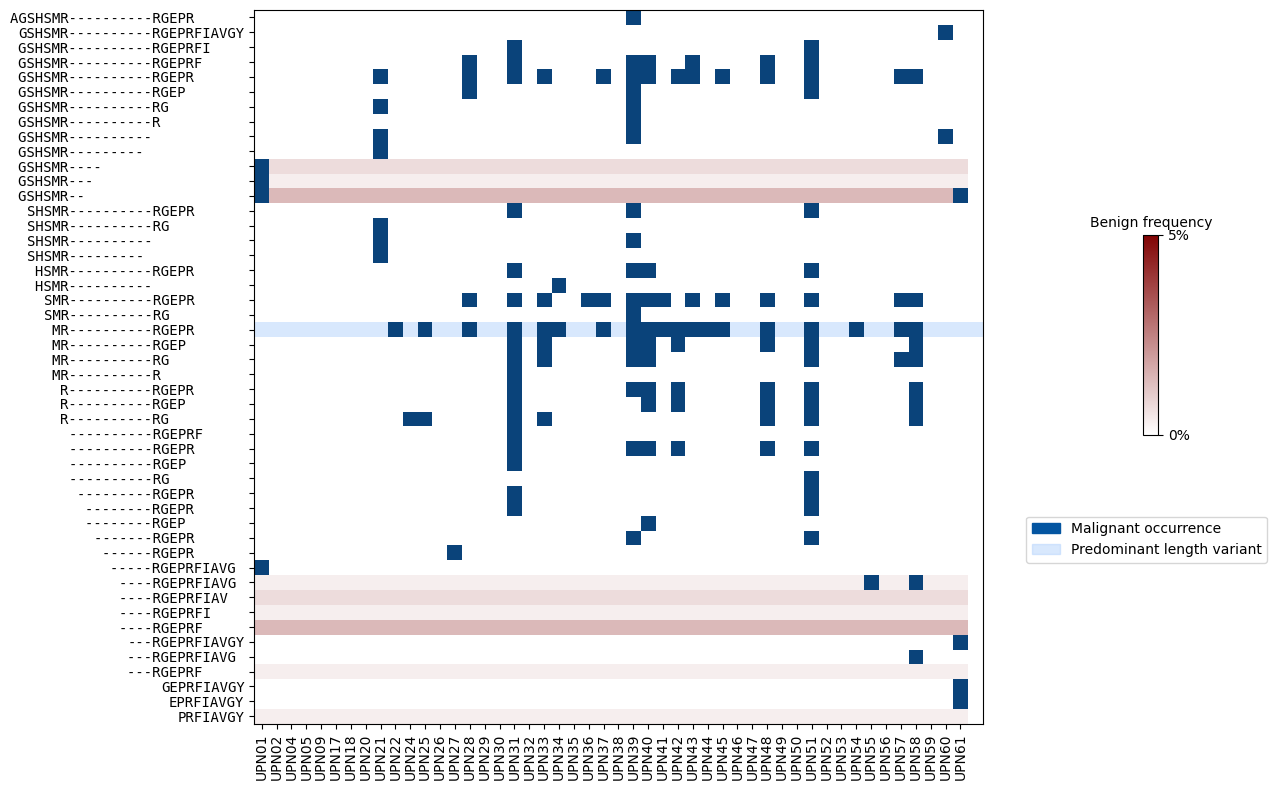

In [ ]:
fig, ax = plt.subplots(1,1,figsize=(15,8))
im, legend_elements = candidate_heatmap('CLL_NELDE_classII_included_9/epitopes.csv', 'AGSHSMRYFYTAMSRPGRGEPRFIAVGY', ax, 0, '',(1.5,0.5), allotype_samples=c2_malignant, n_benign=c2_benign_n, vmax=0.05)
cbar_ax2 = fig.add_axes([0.85,0.45,0.01,0.25])
cbar2=fig.colorbar(mpl.cm.ScalarMappable(cmap=colors.LinearSegmentedColormap.from_list('',['white', "#810404"])), cax=cbar_ax2,shrink=0.3)
cbar2.ax.set_title('Benign frequency', fontdict={'size':'10'})
cbar2.set_ticks(ticks=[0,1], labels=['0%','5%'])
ax.legend(handles=legend_elements, bbox_to_anchor=(1.4,0.3))
plt.tight_layout()
plt.savefig('figures/CLL_epicore_candidate_included2.svg', bbox_inches='tight')

### Class1

In [97]:
class1_df = pd.read_csv('CLL_NELDE_class1.csv', usecols=['sample', 'condition'])
c1_benign_n = len(class1_df[class1_df['condition'].str.contains('benign')]['sample'].unique())
c1_malignant = class1_df[class1_df['condition'].str.contains('malignant')]['sample'].unique()

#### A*02

In [3]:
# calculate consensus and peptide frequencies for A*02
consfreq_A02_included = consensus_frequency('CLL_NELDE_classI_included/epitopes.csv','A*02')
pepfreq_A02 = peptide_frequency('CLL_NELDE_class1.csv','A*02')

# combine frequencies
consfreq_A02_included['grouped_peptides_sequence'] = consfreq_A02_included['grouped_peptides_sequence'].apply(lambda sequences: set(itertools.chain(*sequences)))
consfreq_A02_included = consfreq_A02_included.explode(['grouped_peptides_sequence'])
freq_A02_included = pd.merge(consfreq_A02_included[['whole_epitopes', 'consensus_epitopes','grouped_peptides_sequence', 'benign_frequency', 'malignant_frequency']], pepfreq_A02[['sequence', 'benign_frequency', 'malignant_frequency']], left_on='grouped_peptides_sequence', right_on='sequence', suffixes=('_epicore','_single'))
sanity_check(freq_A02_included)

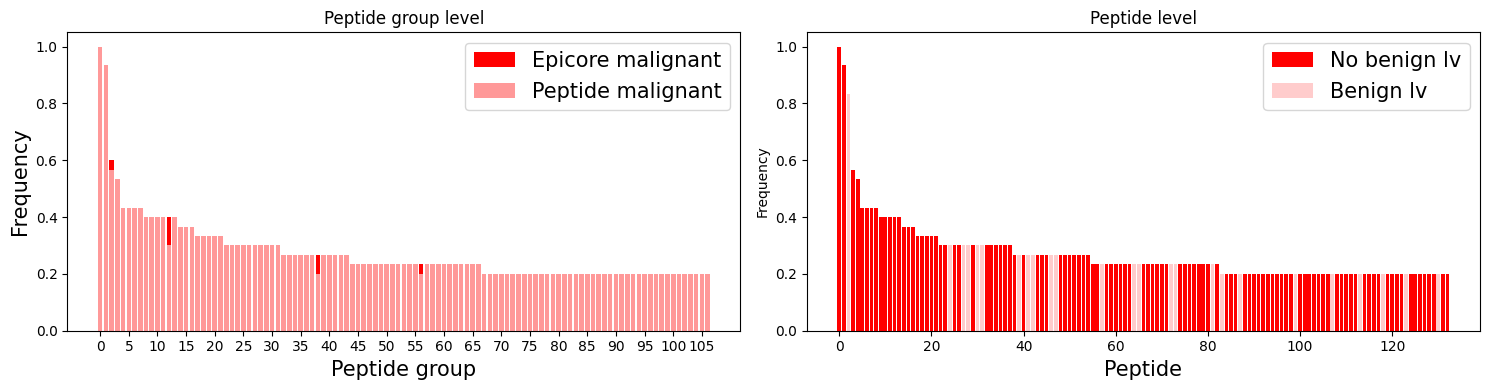

In [9]:
# benign frequency 0% and malignant frequency >= 20%
fig, axis = plt.subplots(1,2, figsize=(15,4))
axis[0].set_title('Peptide group level')
axis[1].set_title('Peptide level')
candidate_region_epicore(freq_A02_included , axis[0], 0.2, 0)
candidate_region_peptide(freq_A02_included , axis[1], 0.2, 0, 0)
axis[1].set_ylabel('Frequency')
plt.tight_layout()
plt.savefig('figures/candidate_region_CLL_A02.svg')

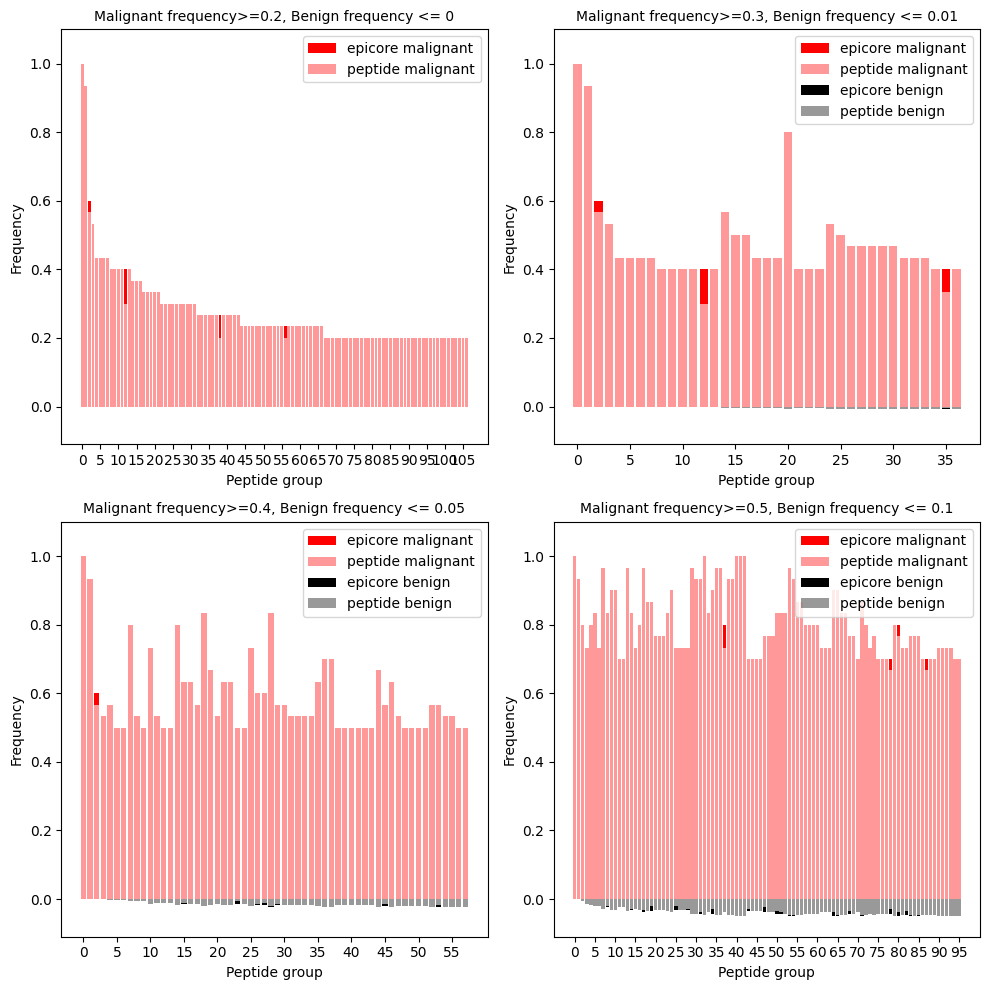

In [ ]:
# plot A02 candidate region for multiple selection thresholds
fig, axis = plt.subplots(2,2, figsize=(10,10))
axis[0,0].set_title('Malignant frequency>=0.2, Benign frequency <= 0', fontdict={'fontsize':10})
candidate_region_epicore(freq_A02_included, axis[0,0], 0.2, 0)
axis[0,0].set_ylim([-0.11, 1.1])
axis[0,1].set_title('Malignant frequency>=0.3, Benign frequency <= 0.01', fontdict={'fontsize':10})
candidate_region_epicore(freq_A02_included, axis[0,1], 0.4, 0.01)
axis[0,1].set_ylim([-0.11, 1.1])
axis[1,0].set_title('Malignant frequency>=0.4, Benign frequency <= 0.05', fontdict={'fontsize':10})
candidate_region_epicore(freq_A02_included, axis[1,0], 0.5, 0.025)
axis[1,0].set_ylim([-0.11, 1.1])
axis[1,1].set_title('Malignant frequency>=0.5, Benign frequency <= 0.1', fontdict={'fontsize':10})
candidate_region_epicore(freq_A02_included, axis[1,1], 0.7, 0.05)
axis[1,1].set_ylim([-0.11, 1.1])
plt.legend()
plt.tight_layout()
plt.savefig('figures/candidate_regions_CLLA02.svg')
plt.show()

In [ ]:
# identify the mean frequency increase in malignant and benign 
freq_A02_duplicated = freq_A02_included[freq_A02_included.duplicated('whole_epitopes', keep=False)]
freqgain_df = freq_A02_duplicated.groupby('whole_epitopes').agg({'benign_frequency_epicore':'first', 'benign_frequency_single':'max', 'malignant_frequency_epicore':'first', 'malignant_frequency_single':'max'})
freqgain_df['benign_increase'] = freqgain_df.apply(lambda row: row['benign_frequency_epicore']-row['benign_frequency_single'], axis=1)
freqgain_df['malignant_increase'] = freqgain_df.apply(lambda row: row['malignant_frequency_epicore']-row['malignant_frequency_single'], axis=1)
print(f"The mean benign frequency increase per peptide group is {freqgain_df['benign_increase'].mean()}")
print(f"The mean malignant frequency increase per peptide group is {freqgain_df['malignant_increase'].mean()}")

The mean benign frequency increase per peptide group is 0.010894972593922385
The mean malignant frequency increase per peptide group is 0.00017880574082005887


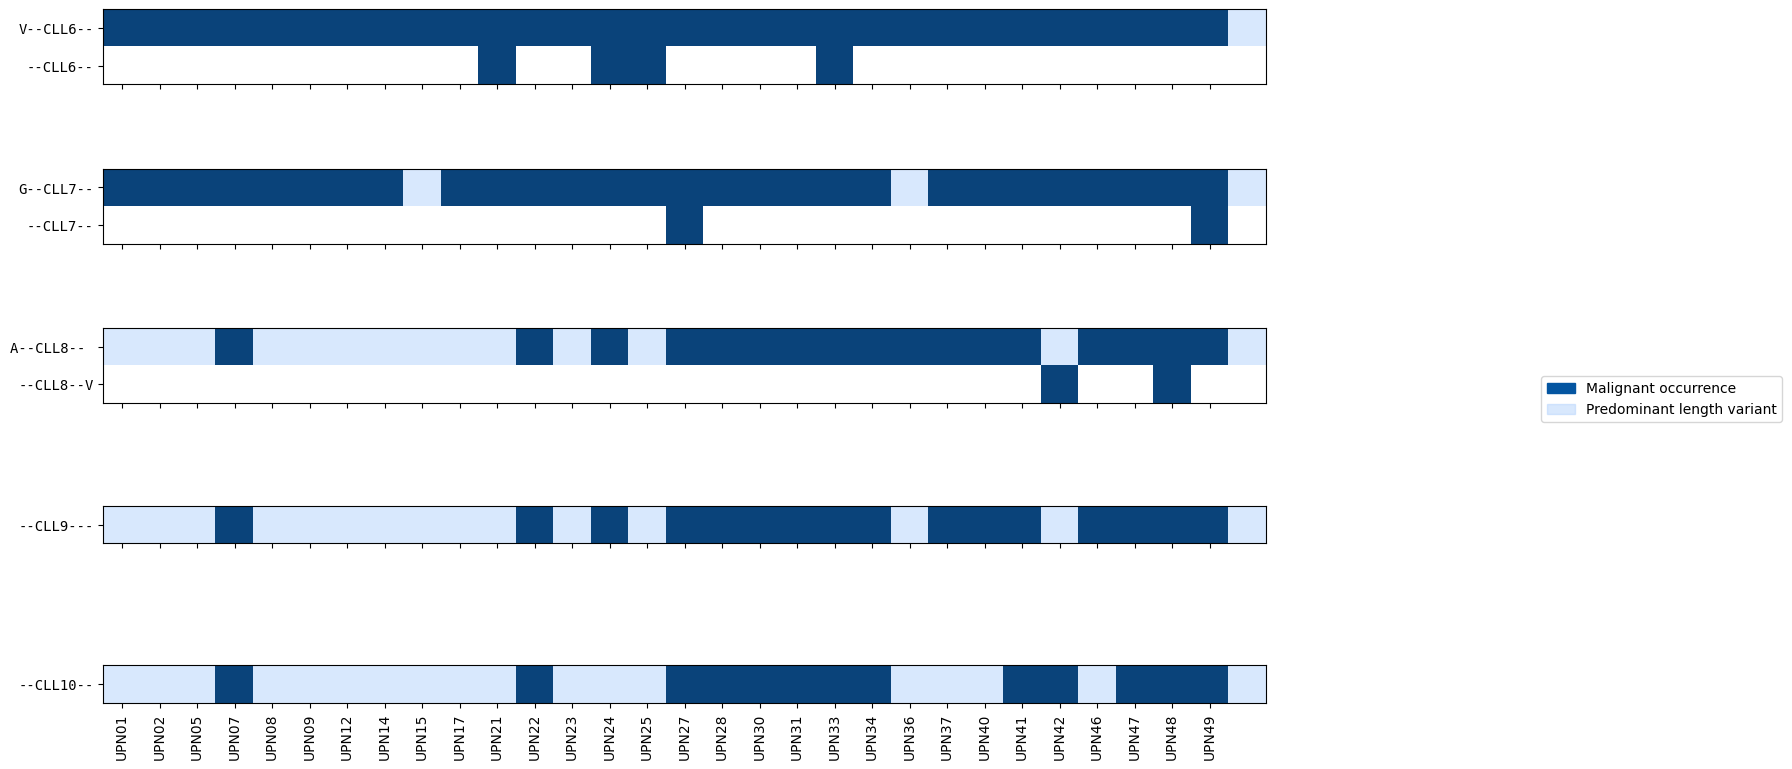

In [ ]:
# identify the candidates
candidate_df_included = freq_A02_included.groupby(['whole_epitopes']).agg({'malignant_frequency_epicore':'first', 'benign_frequency_epicore':'first', 'malignant_frequency_single':'max', 'benign_frequency_single':'max'})
candidate_df_included = candidate_df_included.sort_values(['benign_frequency_epicore', 'malignant_frequency_epicore'], ascending=[True, False])
epicore_A02_candidates = candidate_df_included.reset_index().head(5)['whole_epitopes'].to_list()

c1_benign_n = len(class1_df[class1_df['condition'].str.contains('benign')]['sample'].unique())
c1_malignant = class1_df[class1_df['condition'].str.contains('malignant')]
c1_malignant = class1_df[class1_df['condition'].str.contains('A*02', regex=False)]['sample'].unique()
fig, ax = plt.subplots(5,1,figsize=(15,10), sharex=True)
candidate_heatmap('CLL_NELDE_classI_included/epitopes.csv', epicore_A02_candidates[0], ax[0], 2, 'CLL6',(1.6,0.5), allotype_samples=c1_malignant, n_benign=c1_benign_n, vmax=0.05)
candidate_heatmap('CLL_NELDE_classI_included/epitopes.csv', epicore_A02_candidates[1], ax[1], 2, 'CLL7',(1.6,0.5), allotype_samples=c1_malignant, n_benign=c1_benign_n, vmax=0.05)
candidate_heatmap('CLL_NELDE_classI_included/epitopes.csv', epicore_A02_candidates[2], ax[2], 2, 'CLL8',(1.6,0.5), allotype_samples=c1_malignant, n_benign=c1_benign_n, vmax=0.05)
candidate_heatmap('CLL_NELDE_classI_included/epitopes.csv', epicore_A02_candidates[3], ax[3], 2, 'CLL9',(1.6,0.5), allotype_samples=c1_malignant, n_benign=c1_benign_n, vmax=0.05)
candidate_heatmap('CLL_NELDE_classI_included/epitopes.csv', epicore_A02_candidates[4], ax[4], 2, 'CLL10',(1.6,0.5), allotype_samples=c1_malignant, n_benign=c1_benign_n, vmax=0.05)
ax[2].legend(handles=legend_elements, bbox_to_anchor=(1.45,0.45))
#plt.tight_layout()
plt.savefig('figures/CLL_epicore_candidate_A02.svg', bbox_inches='tight')

In [98]:
# calculate consensus and peptide frequencies for A*02
consfreq_A24_included = consensus_frequency('CLL_NELDE_classI_included/epitopes.csv','A*24')
pepfreq_A24 = peptide_frequency('CLL_NELDE_class1.csv','A*24')

# combine frequencies
consfreq_A24_included['grouped_peptides_sequence'] = consfreq_A24_included['grouped_peptides_sequence'].apply(lambda sequences: set(itertools.chain(*sequences)))
consfreq_A24_included = consfreq_A24_included.explode(['grouped_peptides_sequence'])
freq_A24_included = pd.merge(consfreq_A24_included[['whole_epitopes', 'consensus_epitopes','grouped_peptides_sequence', 'benign_frequency', 'malignant_frequency']], pepfreq_A24[['sequence', 'benign_frequency', 'malignant_frequency']], left_on='grouped_peptides_sequence', right_on='sequence', suffixes=('_epicore','_single'))
sanity_check(freq_A24_included)

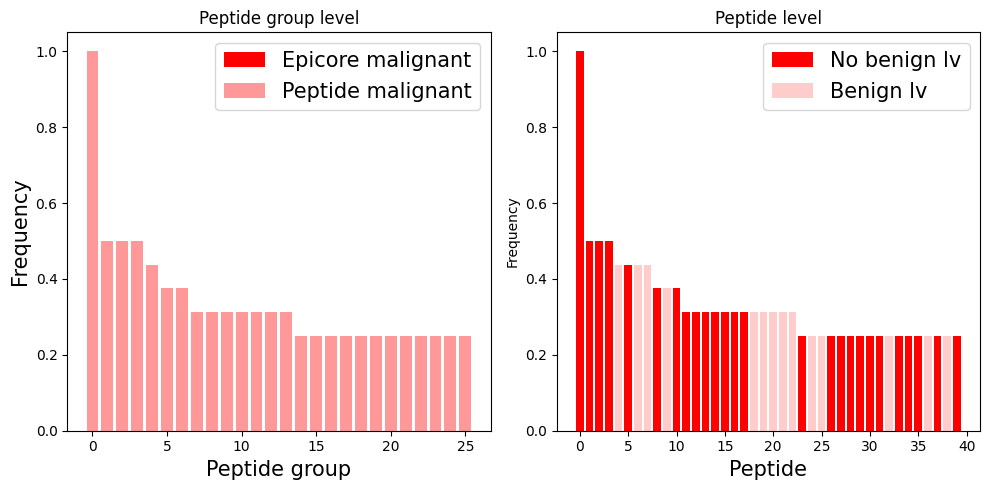

In [104]:
# benign frequency 0% and malignant frequency >= 20%
fig, axis = plt.subplots(1,2, figsize=(10,5))
axis[0].set_title('Peptide group level')
axis[1].set_title('Peptide level')
candidate_region_epicore(freq_A24_included , axis[0], 0.2, 0)
candidate_region_peptide(freq_A24_included , axis[1], 0.2, 0, 0)
axis[1].set_ylabel('Frequency')
plt.tight_layout()
plt.savefig('figures/candidate_region_CLL_A24.svg')

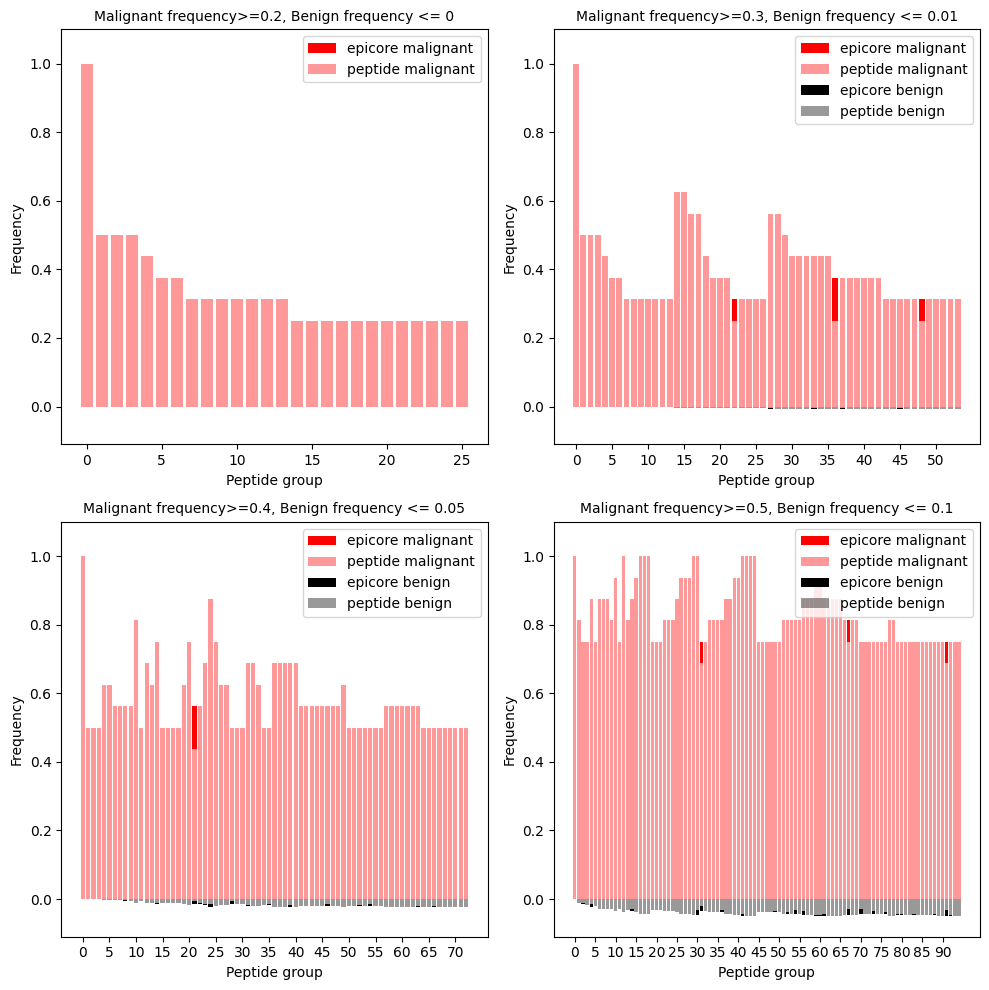

In [ ]:
# plot A24 candidate region for multiple selection thresholds
fig, axis = plt.subplots(2,2, figsize=(10,10))
axis[0,0].set_title('Malignant frequency>=0.2, Benign frequency <= 0', fontdict={'fontsize':10})
candidate_region_epicore(freq_A24_included, axis[0,0], 0.2, 0)
axis[0,0].set_ylim([-0.11, 1.1])
axis[0,1].set_title('Malignant frequency>=0.3, Benign frequency <= 0.01', fontdict={'fontsize':10})
candidate_region_epicore(freq_A24_included, axis[0,1], 0.3, 0.01)
axis[0,1].set_ylim([-0.11, 1.1])
axis[1,0].set_title('Malignant frequency>=0.4, Benign frequency <= 0.05', fontdict={'fontsize':10})
candidate_region_epicore(freq_A24_included, axis[1,0], 0.5, 0.025)
axis[1,0].set_ylim([-0.11, 1.1])
axis[1,1].set_title('Malignant frequency>=0.5, Benign frequency <= 0.1', fontdict={'fontsize':10})
candidate_region_epicore(freq_A24_included, axis[1,1], 0.7, 0.05)
axis[1,1].set_ylim([-0.11, 1.1])
plt.legend()
plt.tight_layout()
plt.savefig('figures/candidate_regions_CLLA24.svg')
plt.show()

In [ ]:
# identify the mean frequency increase in malignant and benign 
freq_A24_duplicated = freq_A24_included[freq_A24_included.duplicated('whole_epitopes', keep=False)]
freqgain_df = freq_A24_duplicated.groupby('whole_epitopes').agg({'benign_frequency_epicore':'first', 'benign_frequency_single':'max', 'malignant_frequency_epicore':'first', 'malignant_frequency_single':'max'})
freqgain_df['benign_increase'] = freqgain_df.apply(lambda row: row['benign_frequency_epicore']-row['benign_frequency_single'], axis=1)
freqgain_df['malignant_increase'] = freqgain_df.apply(lambda row: row['malignant_frequency_epicore']-row['malignant_frequency_single'], axis=1)
print(f"The mean benign frequency increase per peptide group is {freqgain_df['benign_increase'].mean()}")
print(f"The mean malignant frequency increase per peptide group is {freqgain_df['malignant_increase'].mean()}")

The mean benign frequency increase per peptide group is 0.010894972593922385
The mean malignant frequency increase per peptide group is 0.00020905994411470763


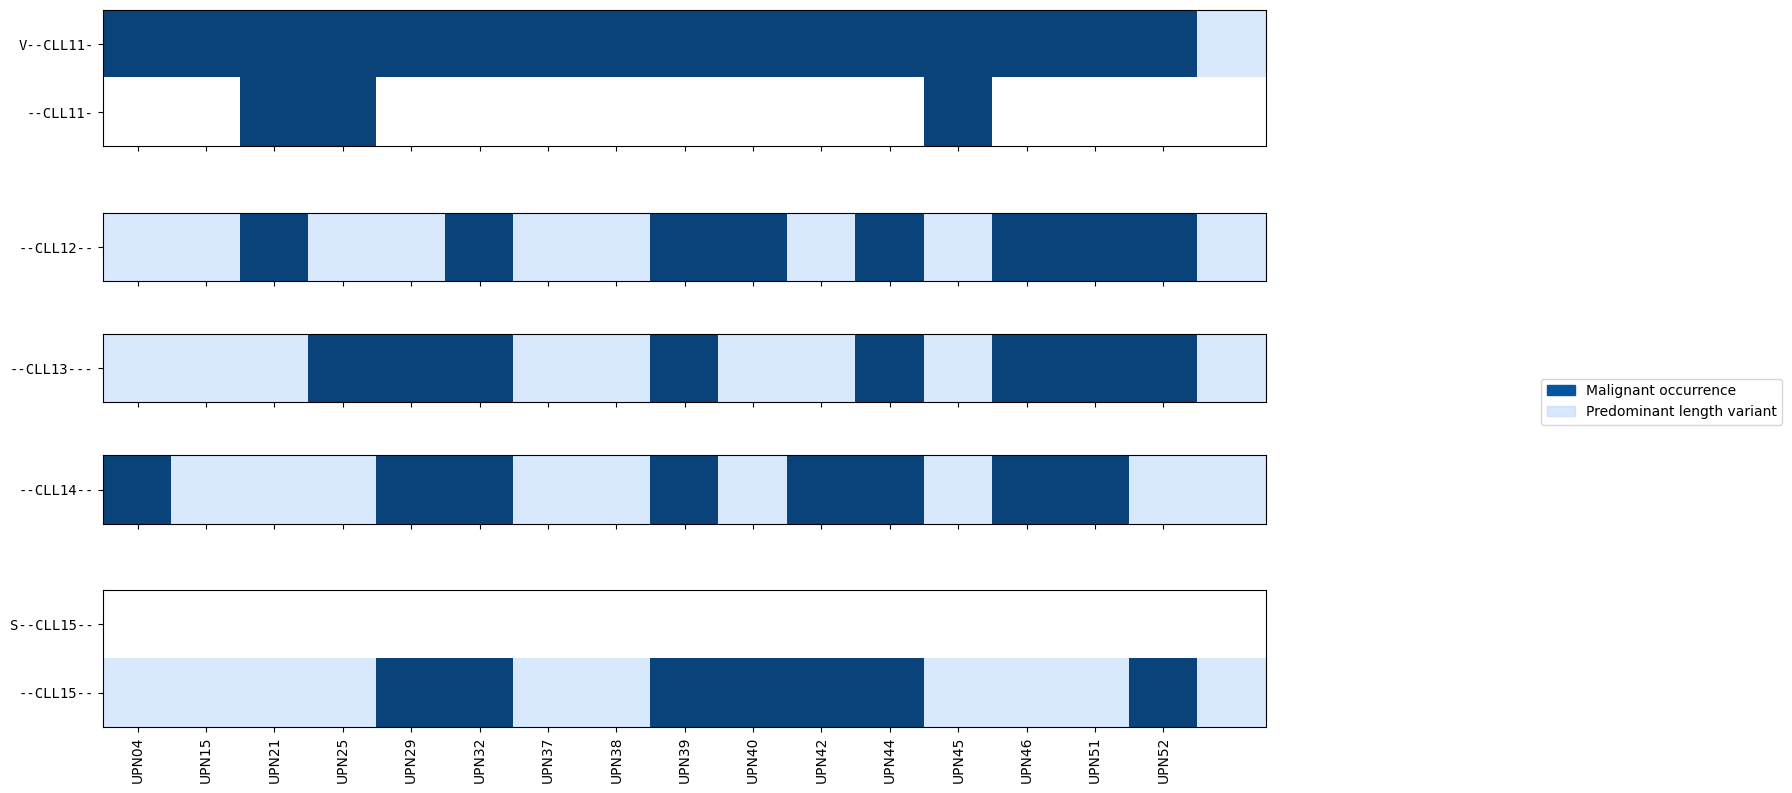

In [ ]:
# identify the candidates
candidate_df_included = freq_A24_included.groupby(['whole_epitopes']).agg({'malignant_frequency_epicore':'first', 'benign_frequency_epicore':'first', 'malignant_frequency_single':'max', 'benign_frequency_single':'max'})
candidate_df_included = candidate_df_included.sort_values(['benign_frequency_epicore', 'malignant_frequency_epicore'], ascending=[True, False])
epicore_A24_candidates = candidate_df_included.reset_index().head(5)['whole_epitopes'].to_list()

c1_benign_n = len(class1_df[class1_df['condition'].str.contains('benign')]['sample'].unique())
c1_malignant = class1_df[class1_df['condition'].str.contains('malignant')]
c1_malignant = class1_df[class1_df['condition'].str.contains('A*24', regex=False)]['sample'].unique()

# plot candidate groups
fig, ax = plt.subplots(5,1,figsize=(15,10), sharex=True, height_ratios=[2/7,1/7,1/7,1/7,2/7])
candidate_heatmap('CLL_NELDE_classI_included/epitopes.csv', epicore_A24_candidates[0], ax[0], 2, 'CLL11',(1.6,0.5), allotype_samples=c1_malignant, n_benign=c1_benign_n, vmax=0.05)
candidate_heatmap('CLL_NELDE_classI_included/epitopes.csv', epicore_A24_candidates[1], ax[1], 2, 'CLL12',(1.6,0.5), allotype_samples=c1_malignant, n_benign=c1_benign_n, vmax=0.05)
candidate_heatmap('CLL_NELDE_classI_included/epitopes.csv', epicore_A24_candidates[2], ax[2], 2, 'CLL13',(1.6,0.5), allotype_samples=c1_malignant, n_benign=c1_benign_n, vmax=0.05)
candidate_heatmap('CLL_NELDE_classI_included/epitopes.csv', epicore_A24_candidates[3], ax[3], 2, 'CLL14',(1.6,0.5), allotype_samples=c1_malignant, n_benign=c1_benign_n, vmax=0.05)
candidate_heatmap('CLL_NELDE_classI_included/epitopes.csv', epicore_A24_candidates[4], ax[4], 2, 'CLL15',(1.6,0.5), allotype_samples=c1_malignant, n_benign=c1_benign_n, vmax=0.05)
ax[2].legend(handles=legend_elements, bbox_to_anchor=(1.45,0.45))
#plt.tight_layout()
plt.savefig('figures/CLL_epicore_candidate_A24.svg', bbox_inches='tight')

In [ ]:
# calculate consensus and peptide frequencies for B*07
consfreq_B07_included = consensus_frequency('CLL_NELDE_classI_included/epitopes.csv','B*07')
pepfreq_B07 = peptide_frequency('CLL_NELDE_class1.csv','B*07')

# combine frequencies
consfreq_B07_included['grouped_peptides_sequence'] = consfreq_B07_included['grouped_peptides_sequence'].apply(lambda sequences: set(itertools.chain(*sequences)))
consfreq_B07_included = consfreq_B07_included.explode(['grouped_peptides_sequence'])
freq_B07_included = pd.merge(consfreq_B07_included[['whole_epitopes', 'consensus_epitopes','grouped_peptides_sequence', 'benign_frequency', 'malignant_frequency']], pepfreq_B07[['sequence', 'benign_frequency', 'malignant_frequency']], left_on='grouped_peptides_sequence', right_on='sequence', suffixes=('_epicore','_single'))
sanity_check(freq_B07_included)

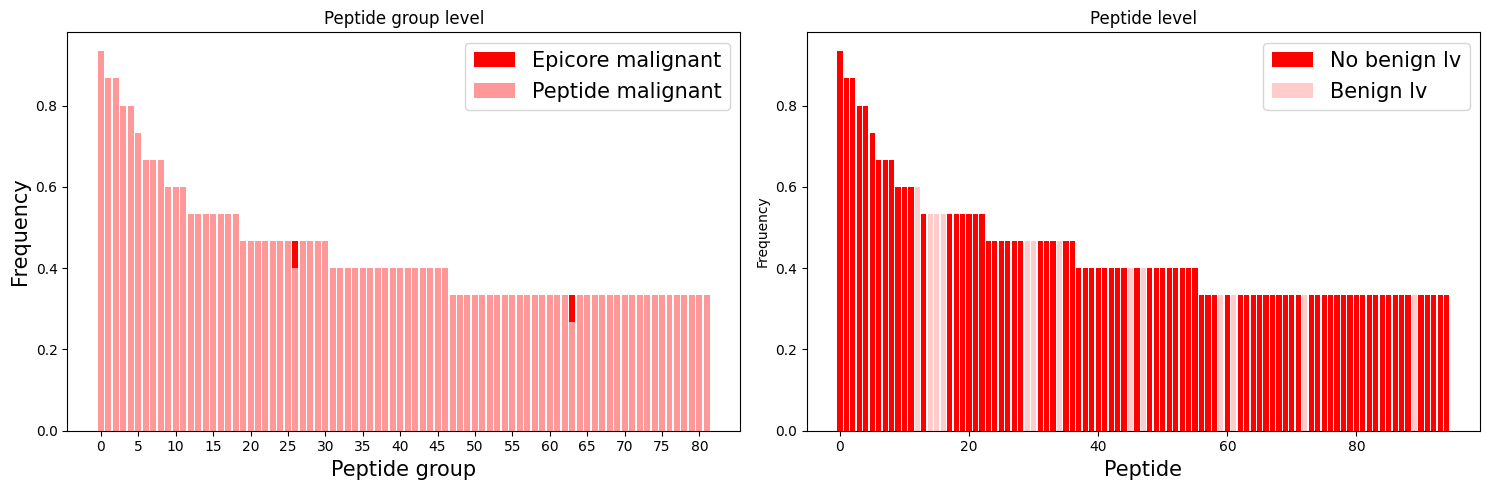

In [12]:
# benign frequency 0% and malignant frequency >= 20%
fig, axis = plt.subplots(1,2, figsize=(15,5))
axis[0].set_title('Peptide group level')
axis[1].set_title('Peptide level')
candidate_region_epicore(freq_B07_included , axis[0], 0.3, 0)
candidate_region_peptide(freq_B07_included , axis[1], 0.3, 0, 0)
axis[1].set_ylabel('Frequency')
plt.tight_layout()
plt.savefig('figures/candidate_region_CLL_B07.svg')

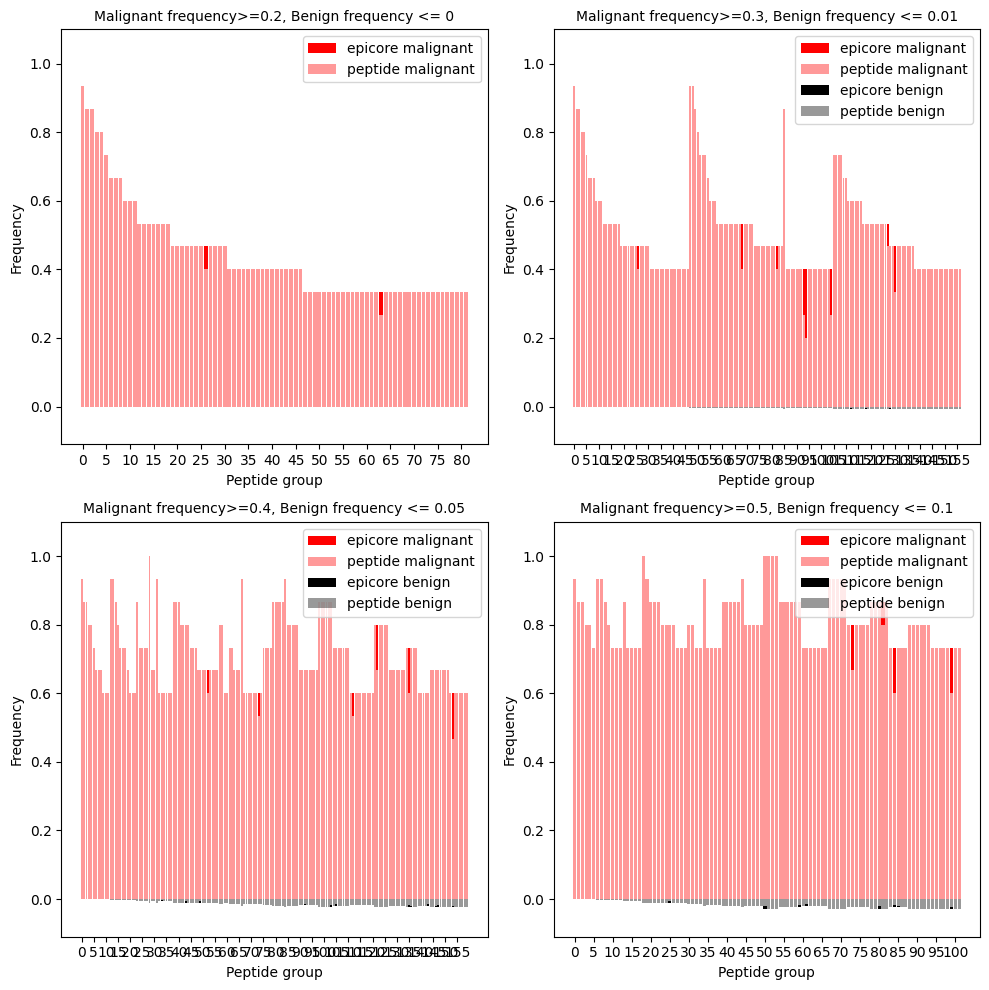

In [ ]:
# plot B07 candidate region for multiple selection thresholds
fig, axis = plt.subplots(2,2, figsize=(10,10))
axis[0,0].set_title('Malignant frequency>=0.2, Benign frequency <= 0', fontdict={'fontsize':10})
candidate_region_epicore(freq_B07_included, axis[0,0], 0.3, 0)
axis[0,0].set_ylim([-0.11, 1.1])
axis[0,1].set_title('Malignant frequency>=0.3, Benign frequency <= 0.01', fontdict={'fontsize':10})
candidate_region_epicore(freq_B07_included, axis[0,1], 0.4, 0.01)
axis[0,1].set_ylim([-0.11, 1.1])
axis[1,0].set_title('Malignant frequency>=0.4, Benign frequency <= 0.05', fontdict={'fontsize':10})
candidate_region_epicore(freq_B07_included, axis[1,0], 0.6, 0.025)
axis[1,0].set_ylim([-0.11, 1.1])
axis[1,1].set_title('Malignant frequency>=0.5, Benign frequency <= 0.1', fontdict={'fontsize':10})
candidate_region_epicore(freq_B07_included, axis[1,1], 0.7, 0.03)
axis[1,1].set_ylim([-0.11, 1.1])
plt.legend()
plt.tight_layout()
plt.savefig('figures/candidate_regions_CLLB07.svg')
plt.show()

In [ ]:
# identify the mean frequency increase in malignant and benign 
freq_B07_duplicated = freq_B07_included[freq_B07_included.duplicated('whole_epitopes', keep=False)]
freqgain_df = freq_B07_duplicated.groupby('whole_epitopes').agg({'benign_frequency_epicore':'first', 'benign_frequency_single':'max', 'malignant_frequency_epicore':'first', 'malignant_frequency_single':'max'})
freqgain_df['benign_increase'] = freqgain_df.apply(lambda row: row['benign_frequency_epicore']-row['benign_frequency_single'], axis=1)
freqgain_df['malignant_increase'] = freqgain_df.apply(lambda row: row['malignant_frequency_epicore']-row['malignant_frequency_single'], axis=1)
print(f"The mean benign frequency increase per peptide group is {freqgain_df['benign_increase'].mean()}")
print(f"The mean malignant frequency increase per peptide group is {freqgain_df['malignant_increase'].mean()}")

The mean benign frequency increase per peptide group is 0.010894972593922385
The mean malignant frequency increase per peptide group is 0.0002801063316268602


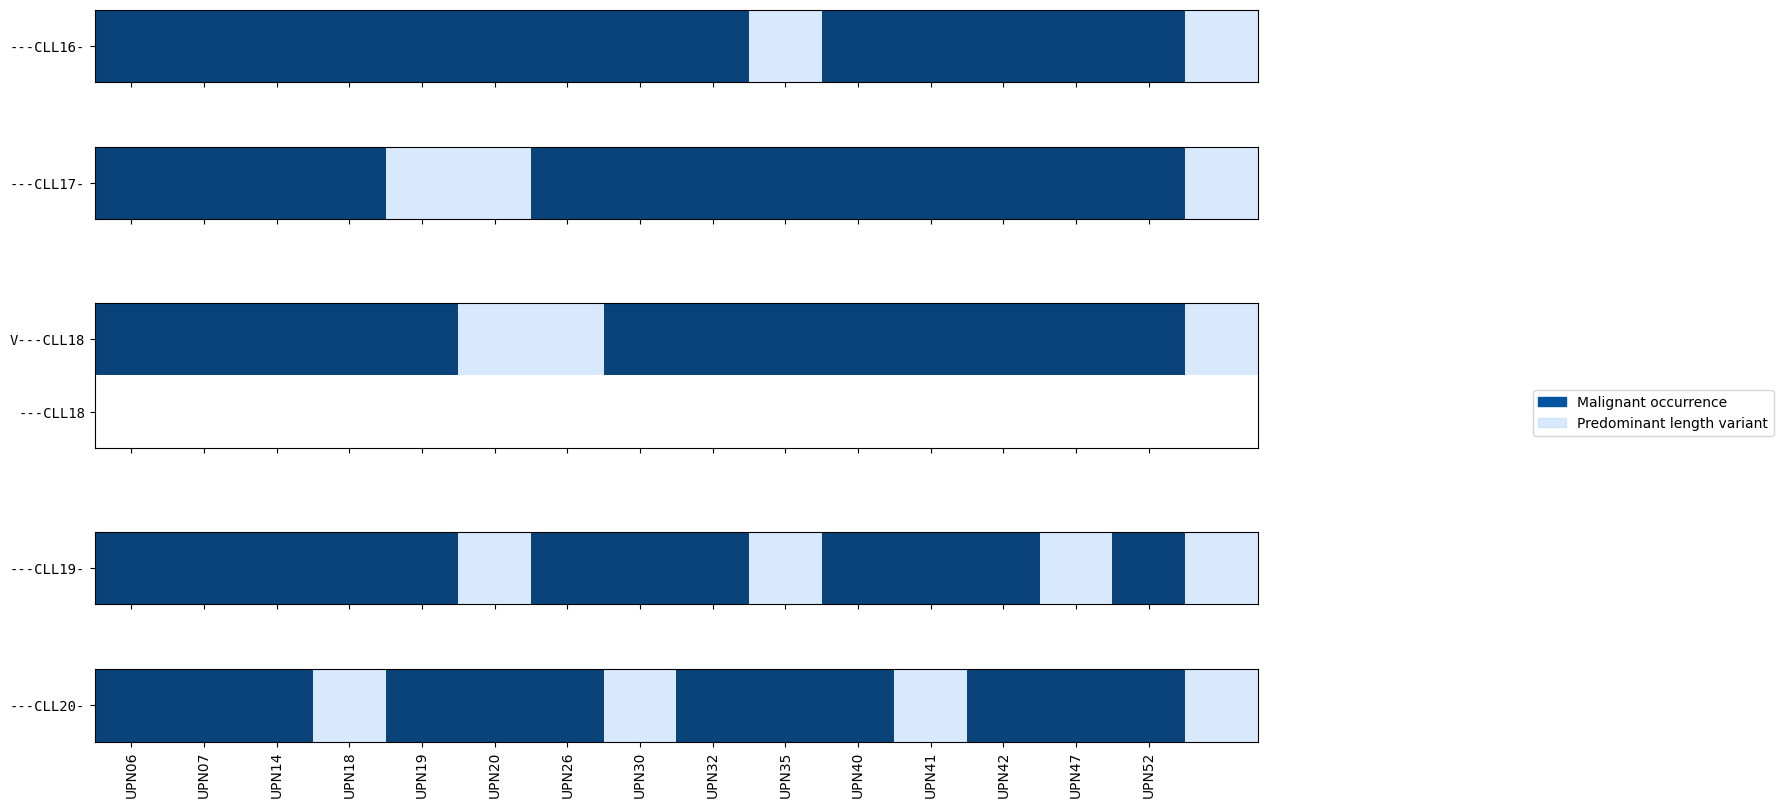

In [ ]:
# identify the candidates
candidate_df_included = freq_B07_included.groupby(['whole_epitopes']).agg({'malignant_frequency_epicore':'first', 'benign_frequency_epicore':'first', 'malignant_frequency_single':'max', 'benign_frequency_single':'max'})
candidate_df_included = candidate_df_included.sort_values(['benign_frequency_epicore', 'malignant_frequency_epicore'], ascending=[True, False])
epicore_B07_candidates = candidate_df_included.reset_index().head(5)['whole_epitopes'].to_list()

c1_benign_n = len(class1_df[class1_df['condition'].str.contains('benign')]['sample'].unique())
c1_malignant = class1_df[class1_df['condition'].str.contains('malignant')]
c1_malignant = class1_df[class1_df['condition'].str.contains('B*07', regex=False)]['sample'].unique()

fig, ax = plt.subplots(5,1,figsize=(15,10), sharex=True, height_ratios=[1/7,1/7,2/7,1/7,1/7])
candidate_heatmap('CLL_NELDE_classI_included/epitopes.csv', epicore_B07_candidates[0], ax[0], 3, 'CLL16',(1.6,0.5), allotype_samples=c1_malignant, n_benign=c1_benign_n, vmax=0.05)
candidate_heatmap('CLL_NELDE_classI_included/epitopes.csv', epicore_B07_candidates[1], ax[1], 3, 'CLL17',(1.6,0.5), allotype_samples=c1_malignant, n_benign=c1_benign_n, vmax=0.05)
candidate_heatmap('CLL_NELDE_classI_included/epitopes.csv', epicore_B07_candidates[2], ax[2], 3, 'CLL18',(1.6,0.5), allotype_samples=c1_malignant, n_benign=c1_benign_n, vmax=0.05)
candidate_heatmap('CLL_NELDE_classI_included/epitopes.csv', epicore_B07_candidates[3], ax[3], 3, 'CLL19',(1.6,0.5), allotype_samples=c1_malignant, n_benign=c1_benign_n, vmax=0.05)
candidate_heatmap('CLL_NELDE_classI_included/epitopes.csv', epicore_B07_candidates[4], ax[4], 3, 'CLL20',(1.6,0.5), allotype_samples=c1_malignant, n_benign=c1_benign_n, vmax=0.05)
ax[2].legend(handles=legend_elements, bbox_to_anchor=(1.45,0.45))
#plt.tight_layout()
plt.savefig('figures/CLL_epicore_candidate_B07.svg', bbox_inches='tight')

In [ ]:
# calculate consensus and peptide frequencies for A*02
consfreq_I_included = consensus_frequency('CLL_NELDE_classI_included/epitopes.csv','')
pepfreq_I = peptide_frequency('CLL_NELDE_class1.csv','')

# combine frequencies
consfreq_I_included['grouped_peptides_sequence'] = consfreq_I_included['grouped_peptides_sequence'].apply(lambda sequences: set(itertools.chain(*sequences)))
consfreq_I_included = consfreq_I_included.explode(['grouped_peptides_sequence'])
freq_I_included = pd.merge(consfreq_I_included[['whole_epitopes', 'consensus_epitopes','grouped_peptides_sequence', 'benign_frequency', 'malignant_frequency']], pepfreq_I[['sequence', 'benign_frequency', 'malignant_frequency']], left_on='grouped_peptides_sequence', right_on='sequence', suffixes=('_epicore','_single'))
sanity_check(freq_I_included)

In [ ]:
# identify the mean frequency increase in malignant and benign 
freq_I_duplicated = freq_I_included[freq_I_included.duplicated('whole_epitopes', keep=False)]
freqgain_df = freq_I_duplicated.groupby('whole_epitopes').agg({'benign_frequency_epicore':'first', 'benign_frequency_single':'max', 'malignant_frequency_epicore':'first', 'malignant_frequency_single':'max'})
freqgain_df['benign_increase'] = freqgain_df.apply(lambda row: row['benign_frequency_epicore']-row['benign_frequency_single'], axis=1)
freqgain_df['malignant_increase'] = freqgain_df.apply(lambda row: row['malignant_frequency_epicore']-row['malignant_frequency_single'], axis=1)
print(f"The mean benign frequency increase per peptide group is {freqgain_df['benign_increase'].mean()}")
print(f"The mean malignant frequency increase per peptide group is {freqgain_df['malignant_increase'].mean()}")

The mean benign frequency increase per peptide group is 0.010894972593922385
The mean malignant frequency increase per peptide group is 0.004457722823383963


## Investigate warehouse candidates

#### Class1

In [ ]:
class1_warehouse_candidates = [['VIAELPPKV','ALHRPDVYL','TLDTSKLYV'],['GYMPYLNRF','KYSKALIDYF','RHTGALPLF'],['SPRVYWLGL','RPSNKAPLL','LPRLEALDL']]
candidate_groups_A02 = freq_A02_included[freq_A02_included['sequence'].isin(class1_warehouse_candidates[0])]['whole_epitopes'].to_list()
candidate_groups_A24 = freq_A24_included[freq_A24_included['sequence'].isin(class1_warehouse_candidates[1])]['whole_epitopes'].to_list()
candidate_groups_B07 = freq_B07_included[freq_B07_included['sequence'].isin(class1_warehouse_candidates[2])]['whole_epitopes'].to_list()

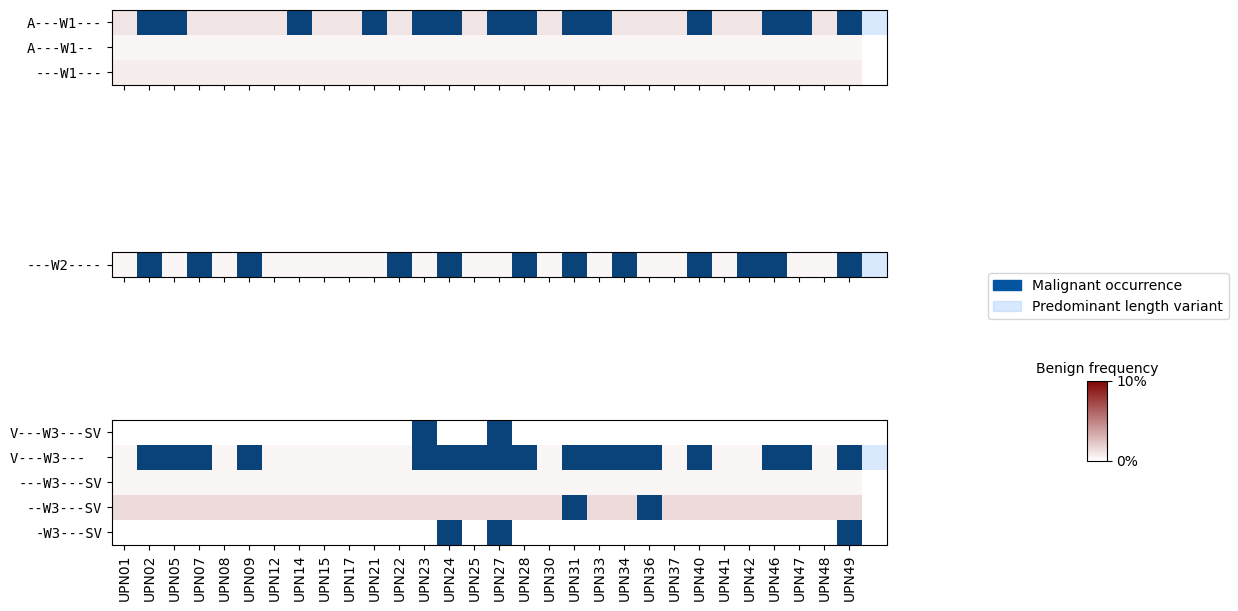

In [ ]:
# identify the candidates

c1_benign_n = len(class1_df[class1_df['condition'].str.contains('benign')]['sample'].unique())
c1_malignant = class1_df[class1_df['condition'].str.contains('malignant')]
c1_malignant = class1_df[class1_df['condition'].str.contains('A*02', regex=False)]['sample'].unique()

fig, ax = plt.subplots(3,1,figsize=(10,8), sharex=True)
candidate_heatmap('CLL_NELDE_classI_included/epitopes.csv', candidate_groups_A02[0], ax[0], 3, 'W1',(1.6,0.5), allotype_samples=c1_malignant, n_benign=c1_benign_n, vmax=0.1)
im, legend_elements = candidate_heatmap('CLL_NELDE_classI_included/epitopes.csv', candidate_groups_A02[1], ax[1], 3, 'W2',(1.6,0.5), allotype_samples=c1_malignant, n_benign=c1_benign_n, vmax=0.1)
candidate_heatmap('CLL_NELDE_classI_included/epitopes.csv', candidate_groups_A02[2], ax[2], [3,3,3,2,1], 'W3',(1.6,0.5), allotype_samples=c1_malignant, n_benign=c1_benign_n, vmax=0.1)
ax[1].legend(handles=legend_elements, bbox_to_anchor=(1.45,0.45))
cmap = colors.LinearSegmentedColormap.from_list('',['white', "#810404"])
cbar_ax2 = fig.add_axes([1.1,0.25,0.02,0.1])
cbar2=fig.colorbar(mpl.cm.ScalarMappable(cmap=cmap), cax=cbar_ax2,shrink=0.3)
cbar2.ax.set_title('Benign frequency', fontdict={'size':'10'})
cbar2.set_ticks(ticks=[0,1], labels=['0%','10%'])
#plt.tight_layout()
plt.savefig('figures/CLL_warehouse_candidate_A02.svg', bbox_inches='tight')

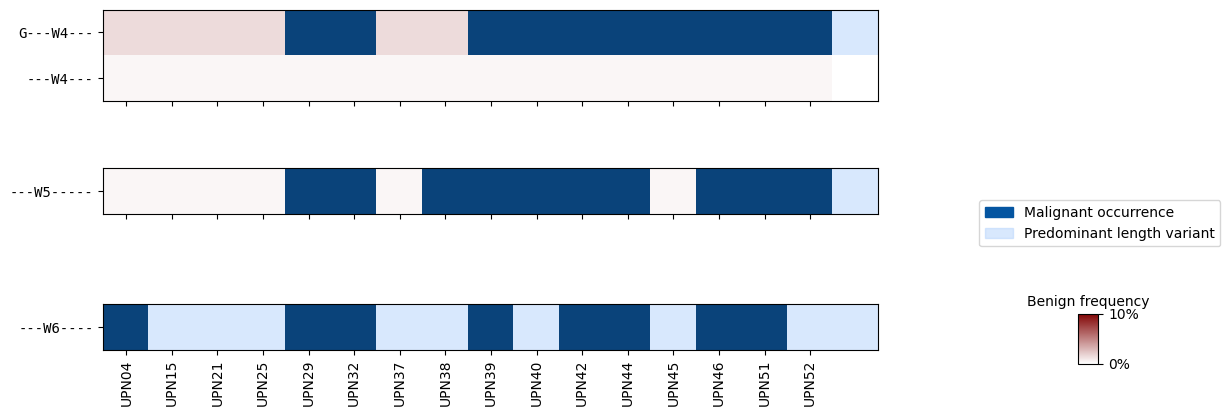

In [ ]:
c1_benign_n = len(class1_df[class1_df['condition'].str.contains('benign')]['sample'].unique())
c1_malignant = class1_df[class1_df['condition'].str.contains('malignant')]
c1_malignant = class1_df[class1_df['condition'].str.contains('A*24', regex=False)]['sample'].unique()

fig, ax = plt.subplots(3,1,figsize=(10,5), sharex=True)
candidate_heatmap('CLL_NELDE_classI_included/epitopes.csv', candidate_groups_A24[0], ax[0], 3, 'W4',(1.6,0.5), allotype_samples=c1_malignant, n_benign=c1_benign_n, vmax=0.1)
candidate_heatmap('CLL_NELDE_classI_included/epitopes.csv', candidate_groups_A24[1], ax[1], 3, 'W5',(1.6,0.5), allotype_samples=c1_malignant, n_benign=c1_benign_n, vmax=0.1)
candidate_heatmap('CLL_NELDE_classI_included/epitopes.csv', candidate_groups_A24[2], ax[2], 3, 'W6',(1.6,0.5), allotype_samples=c1_malignant, n_benign=c1_benign_n, vmax=0.1)
ax[1].legend(handles=legend_elements, bbox_to_anchor=(1.45,0.45))
cmap = colors.LinearSegmentedColormap.from_list('',['white', "#810404"])
cbar_ax2 = fig.add_axes([1.1,0.15,0.02,0.1])
cbar2=fig.colorbar(mpl.cm.ScalarMappable(cmap=cmap), cax=cbar_ax2,shrink=0.3)
cbar2.ax.set_title('Benign frequency', fontdict={'size':'10'})
cbar2.set_ticks(ticks=[0,1], labels=['0%','10%'])
plt.savefig('figures/CLL_warehouse_candidate_A24.svg', bbox_inches='tight')

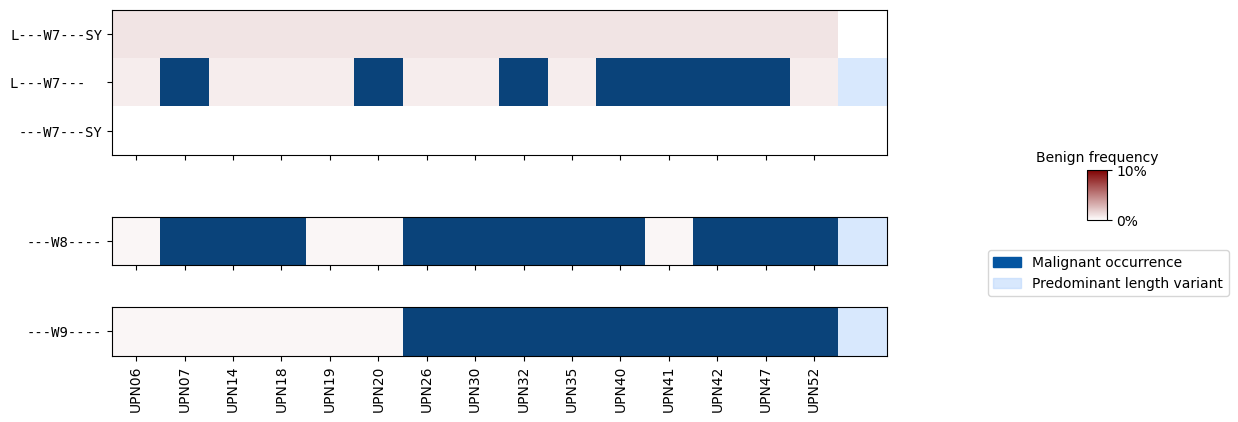

In [ ]:
c1_benign_n = len(class1_df[class1_df['condition'].str.contains('benign')]['sample'].unique())
c1_malignant = class1_df[class1_df['condition'].str.contains('malignant')]
c1_malignant = class1_df[class1_df['condition'].str.contains('B*07', regex=False)]['sample'].unique()

fig, ax = plt.subplots(3,1,figsize=(10,5), sharex=True, height_ratios=[3/5, 1/5, 1/5])
candidate_heatmap('CLL_NELDE_classI_included/epitopes.csv', candidate_groups_B07[0], ax[0], 3, 'W7',(1.6,0.5), allotype_samples=c1_malignant, n_benign=c1_benign_n, vmax=0.1)
candidate_heatmap('CLL_NELDE_classI_included/epitopes.csv', candidate_groups_B07[1], ax[1], 3, 'W8',(1.6,0.5), allotype_samples=c1_malignant, n_benign=c1_benign_n, vmax=0.1)
candidate_heatmap('CLL_NELDE_classI_included/epitopes.csv', candidate_groups_B07[2], ax[2], 3, 'W9',(1.6,0.5), allotype_samples=c1_malignant, n_benign=c1_benign_n, vmax=0.1)
ax[1].legend(handles=legend_elements, bbox_to_anchor=(1.45,0.45))
cmap = colors.LinearSegmentedColormap.from_list('',['white', "#810404"])
cbar_ax2 = fig.add_axes([1.1,0.4,0.02,0.1])
cbar2=fig.colorbar(mpl.cm.ScalarMappable(cmap=cmap), cax=cbar_ax2,shrink=0.3)
cbar2.ax.set_title('Benign frequency', fontdict={'size':'10'})
cbar2.set_ticks(ticks=[0,1], labels=['0%','10%'])
plt.savefig('figures/CLL_warehouse_candidate_B07.svg', bbox_inches='tight')

#### Class 2

In [22]:
# identify the peptide groups of the warehouse peptides
class2_warehouse_candidates = ['GSSFFGELFNQNPE','QPPDWLQGHYLVVRYEDL','YPDRPGWLRYIQRTPYSDG','DHAQLVAIKTLKDYNNPQ','LLLILRDPSERVLSDY']
candidate_groups = freq_cII_included[freq_cII_included['sequence'].isin(class2_warehouse_candidates)]['whole_epitopes'].to_list()

In [20]:
class2_df = pd.read_csv('CLL_NELDE_class2.csv', usecols=['sample', 'condition'])
c2_benign_n = len(class2_df[class2_df['condition'].str.contains('benign')]['sample'].unique())
c2_malignant = class2_df[class2_df['condition'].str.contains('malignant')]['sample'].unique()

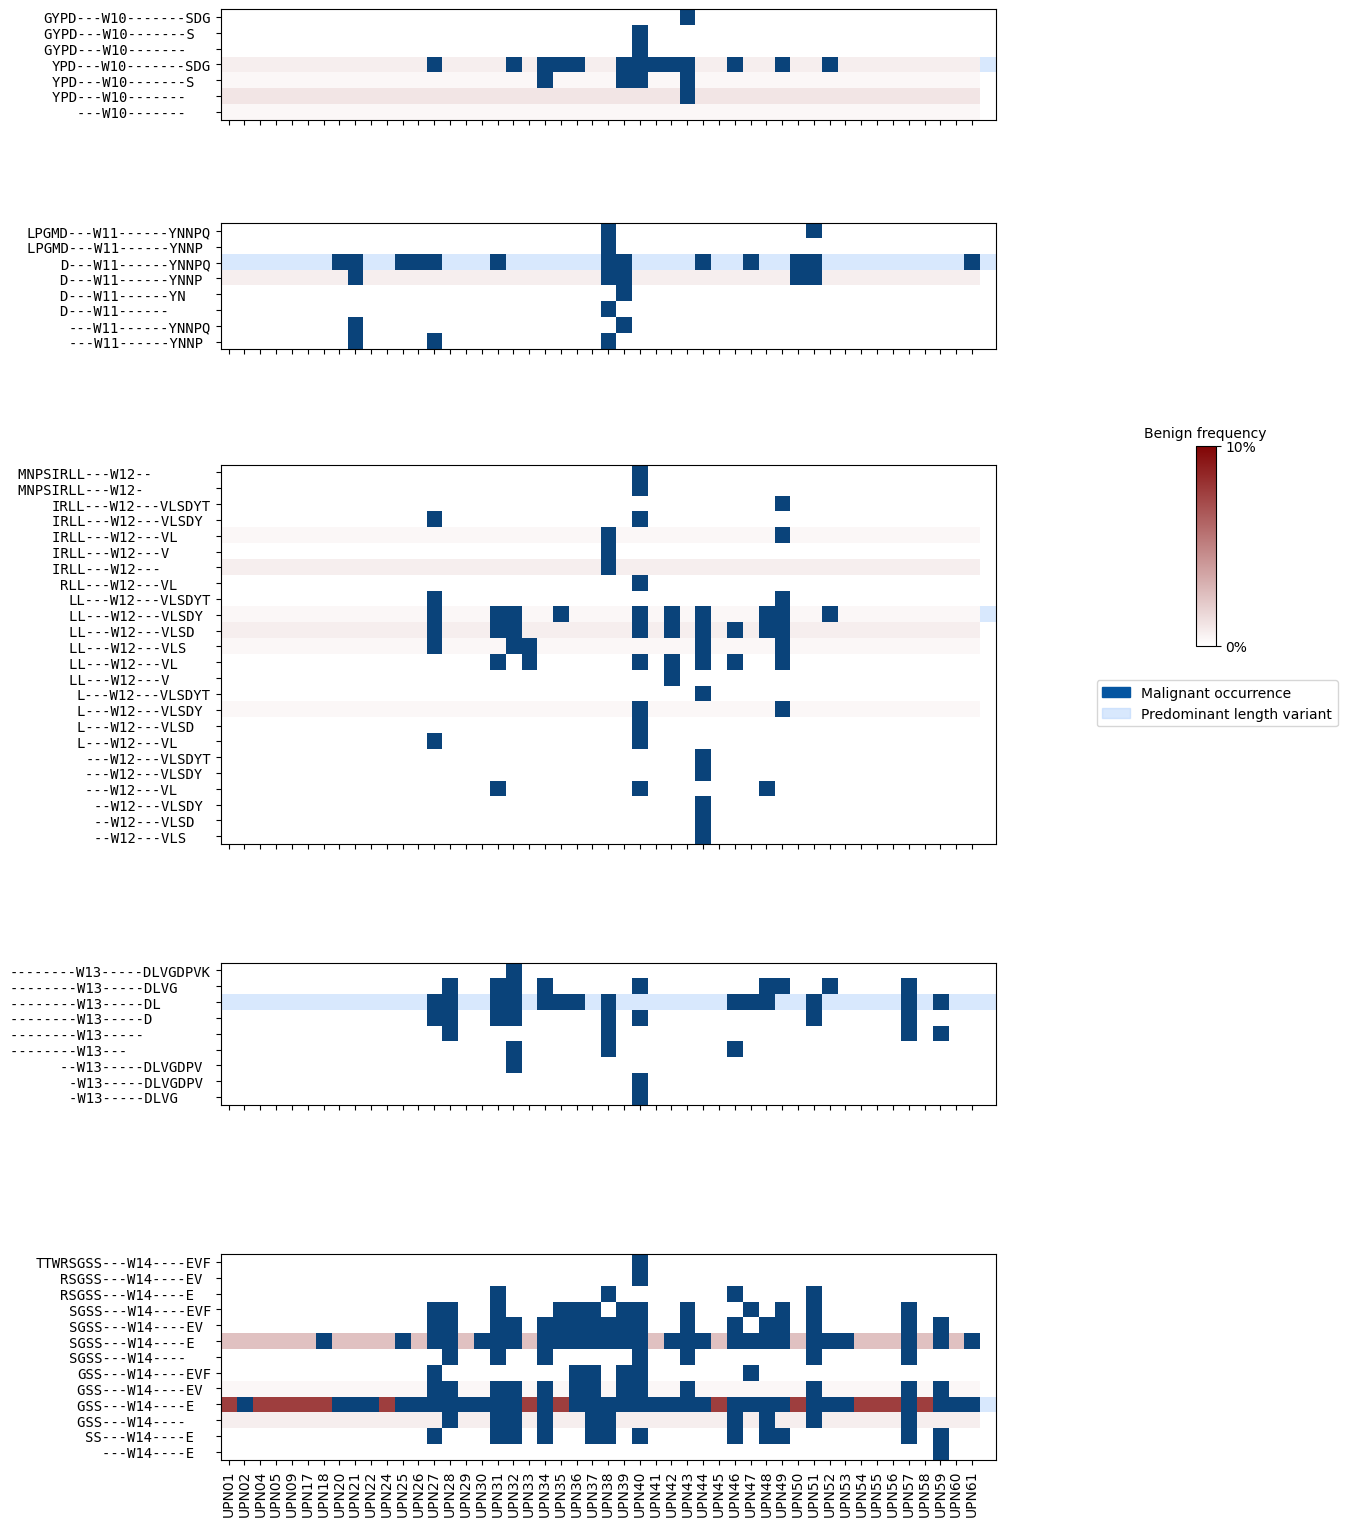

In [23]:
c2_benign_n = len(class2_df[class2_df['condition'].str.contains('benign')]['sample'].unique())
c2_malignant = class2_df[class2_df['condition'].str.contains('malignant')]['sample'].unique()

fig, ax = plt.subplots(5,1,figsize=(10,20), sharex=True, height_ratios=[7,8,20,9,15])
candidate_heatmap('CLL_NELDE_classII_included_9/epitopes.csv', candidate_groups[0], ax[0], 3, 'W10',(1.6,0.5), allotype_samples=c2_malignant, n_benign=c2_benign_n, vmax=0.1)
candidate_heatmap('CLL_NELDE_classII_included_9/epitopes.csv', candidate_groups[1], ax[1], 3, 'W11',(1.6,0.5), allotype_samples=c2_malignant, n_benign=c2_benign_n, vmax=0.1)
im, legend_elements = candidate_heatmap('CLL_NELDE_classII_included_9/epitopes.csv', candidate_groups[2], ax[2], [3]*21+[2]*3, 'W12',(1.6,0.5), allotype_samples=c2_malignant, n_benign=c2_benign_n, vmax=0.1)
candidate_heatmap('CLL_NELDE_classII_included_9/epitopes.csv', candidate_groups[3], ax[3], [8,8,8,8,8,8,2,1,1], 'W13',(1.6,0.5), allotype_samples=c2_malignant, n_benign=c2_benign_n, vmax=0.1)
candidate_heatmap('CLL_NELDE_classII_included_9/epitopes.csv', candidate_groups[4], ax[4], 3, 'W14',(1.6,0.5), allotype_samples=c2_malignant, n_benign=c2_benign_n, vmax=0.1)
ax[2].legend(handles=legend_elements, bbox_to_anchor=(1.45,0.45))

cmap = colors.LinearSegmentedColormap.from_list('',['white', "#810404"])
cbar_ax2 = fig.add_axes([1.1,0.55,0.02,0.1])
cbar2=fig.colorbar(mpl.cm.ScalarMappable(cmap=cmap), cax=cbar_ax2,shrink=0.3)
cbar2.ax.set_title('Benign frequency', fontdict={'size':'10'})
cbar2.set_ticks(ticks=[0,1], labels=['0%','10%'])
plt.savefig('figures/CLL_warehouse_candidate_c2.svg', bbox_inches='tight')

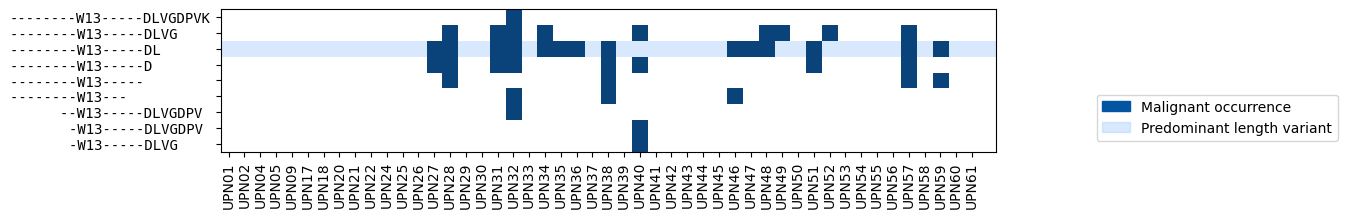

In [ ]:
fig, ax = plt.subplots(1,1,figsize=(10,20))
im, legend_elements =candidate_heatmap('CLL_NELDE_classII_included_9/epitopes.csv', candidate_groups[3], ax, [8,8,8,8,8,8,2,1,1], 'W13',(1.6,0.5), allotype_samples=c2_malignant, n_benign=c2_benign_n, vmax=0.1)
ax.legend(handles=legend_elements, bbox_to_anchor=(1.45,0.45))


cbar2.set_ticks(ticks=[0,1], labels=['0%','10%'])
plt.savefig('figures/CLL_warehouse_lv.svg', bbox_inches='tight')

Plot the epicore candidate region, that highlights the peptides of the CLL warehouse.

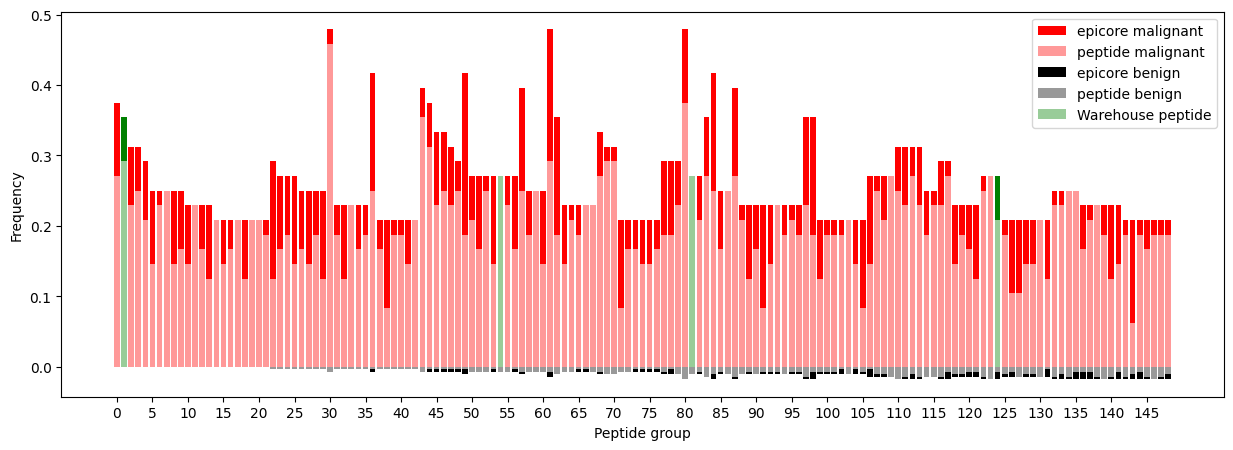

In [ ]:
fig, axis = plt.subplots(1,1, figsize=(15,5))
candidate_region_epicore_highlighted(freq_cII_included , axis, 0.2, 0.02, candidate_groups)
plt.savefig('figures/CLL_warehouse_highlighted.svg')